<a href="https://colab.research.google.com/github/Katrin-Pochtar/Kaggle/blob/main/%D0%9F%D0%BE%D1%87%D1%82%D0%B0%D1%80_%D0%9A%D0%B0%D1%82%D1%80%D0%B8%D0%BD_%D0%92%D0%B8%D0%BA%D1%82%D0%BE%D1%80%D0%BE%D0%B2%D0%BD%D0%B0_%D0%A1%D0%BE%D1%80%D0%B5%D0%B2%D0%BD%D0%BE%D0%B2%D0%B0%D1%82%D0%B5%D0%BB%D1%8C%D0%BD%D1%8B%D0%B9_DS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# План домашних заданий





- Описание задачи и знакомство с данными.
- Домашнее задание 1. Генерация и фильтрация признаков.
- Домашнее задание 2. Прогноз времени и вида поломки машин, настройка ML-модели.
- Домашнее задание 3. Оптимизация. Тюнинг гиперпараметров с помощью `Optuna`.
- Домашнее задание 4. Блендинг.
- Домашнее задание 5. Парсинг внешних данных и оптимизация памяти.


In [1]:
!nvidia-smi

Mon May  4 04:09:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.142                Driver Version: 580.142        CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090        Off |   00000000:0B:00.0  On |                  N/A |
|  0%   35C    P8             20W /  350W |    1682MiB /  24576MiB |      1%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import data_table
data_table.enable_dataframe_formatter()

# <center id="part0"> Описание задачи

**Предыстория:**  мы работаем с каршеринговой компанией, которая управляет крупным автопарком машин. Наша цель — предотвратить длительные периоды простоя машин из-за поломок через своевременное обслуживание и ремонт.


**Идея для решения проблемы:** создать приоритизированный список обхода машин. Этот список поможет технической бригаде сосредоточиться на автомобилях, которые наиболее вероятно выйдут из строя в ближайшее время.


**Как компания решает задачу:**

* собирает данные о поездках и состоянии машин до поломок;

* нанимает Data Scientist, чтобы он смог использовать эти данные для анализа и прогнозирования характера поломок.

**Важный момент**: задачи этого специалиста (Data Scientist) предстоит выполнять вам.

## <center> Знакомство с данными

### Информация про машины с таргетом (основной датасет)

In [4]:
car_train = pd.read_csv('https://raw.githubusercontent.com/a-milenkin/Competitive_Data_Science/main/data/car_train.csv')
car_train.sample(5)

,car_id,model,car_type,fuel_type,car_rating,year_to_start,riders,year_to_work,target_reg,target_class
1809,l-1177682G,Tesla Model 3,premium,electro,4.46,2016,105697,2020,77.98,engine_check
659,N-5708757B,Kia Rio X-line,economy,petrol,4.82,2013,44278,2018,36.82,engine_overheat
576,V-9725752D,Nissan Qashqai,standart,petrol,4.18,2013,49244,2019,53.08,engine_ignition
806,v-1935966T,Hyundai Solaris,economy,petrol,4.70,2012,22882,2017,43.95,engine_overheat
1837,t-8867045F,Kia Sportage,standart,petrol,3.54,2015,95693,2014,103.47,another_bug


- `car_id` — идентификатор машины;
- `model` / `car_type` / `fuel_type` — марка, класс и тип топлива машины;
- `car_rating` / `riders` — общий рейтинг и общее число поездок к концу 2021 года;
- `year_to_start` / `year_to_work` — год выпуска машины и год начала работы в автопарке;
- `target_reg` — количество дней до поломки;
- `target_class` — класс поломки (всего 9 видов).

(2337, 10)


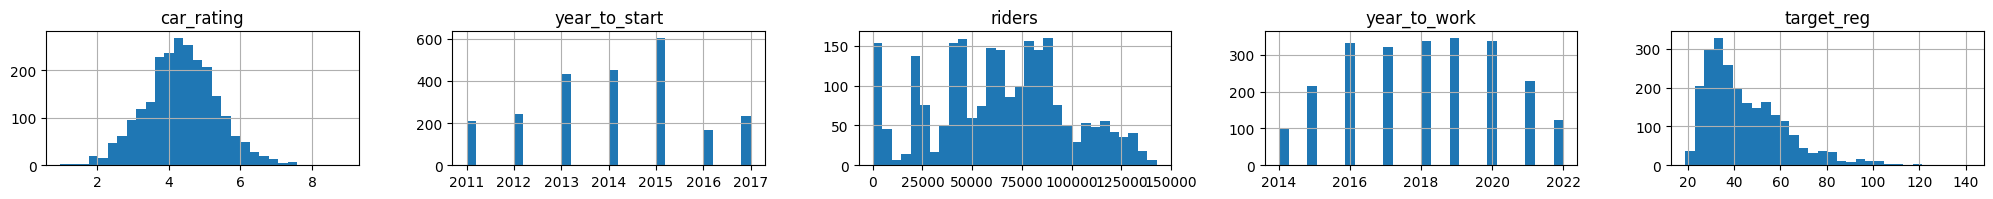

In [5]:
print(car_train.shape)
car_train.hist(figsize=(25, 4), layout=(2, 5), bins=30);

### Информация про поездки

In [6]:
rides_info = pd.read_csv('https://raw.githubusercontent.com/a-milenkin/Competitive_Data_Science/main/data/rides_info.csv')
rides_info.sample(5)

,user_id,car_id,ride_id,ride_date,rating,ride_duration,ride_cost,speed_avg,speed_max,stop_times,distance,refueling,user_ride_quality,deviation_normal
554424,z22767421c,n-1774226C,o1X,2020-02-02,4.62,4,51,54,84.000000,1,230.757432,0,10.881417,0.000
157842,i97460131K,L-3013668o,x1I,2020-01-13,2.92,28,443,72,144.307248,0,1934.009981,0,-9.834667,-49.468
544966,t60474556e,m10508273p,E1V,2020-04-01,6.43,53,632,49,82.000000,0,2107.560105,0,-9.185742,-15.779
473227,V13142251t,h-7408890w,V1d,2020-03-05,3.88,46,501,32,42.000000,2,774.849880,0,5.877311,4.327
496658,d11450017F,i99395396b,i1l,2020-02-03,5.81,47,557,52,68.000000,0,2483.015475,0,5.996958,32.800


- `user_id` / `car_id` / `ride_id` — идентификаторы водителя, машины и поездки соответственно;
- `ride_date` / `rating` — дата поездки и рейтинг, поставленный водителем;
- `ride_duration` / `distance` / `ride_cost` —  длительность (время),  пройденное расстояние, стоимость поездки;
- `speed_avg` / `speed_max` — средняя и максимальная скорости поездки соответственно;
- `stop_times` / `refueling` — количество остановок (паузы) и флаг: была ли дозаправка;
- `user_ride_quality` — оценка манеры вождения водителя машины, определенная скоринговой ML-системой сервиса;
- `deviation_normal` — общий показатель датчиков о состоянии машины, относительно эталонных показателей (нормы).

(739500, 14)


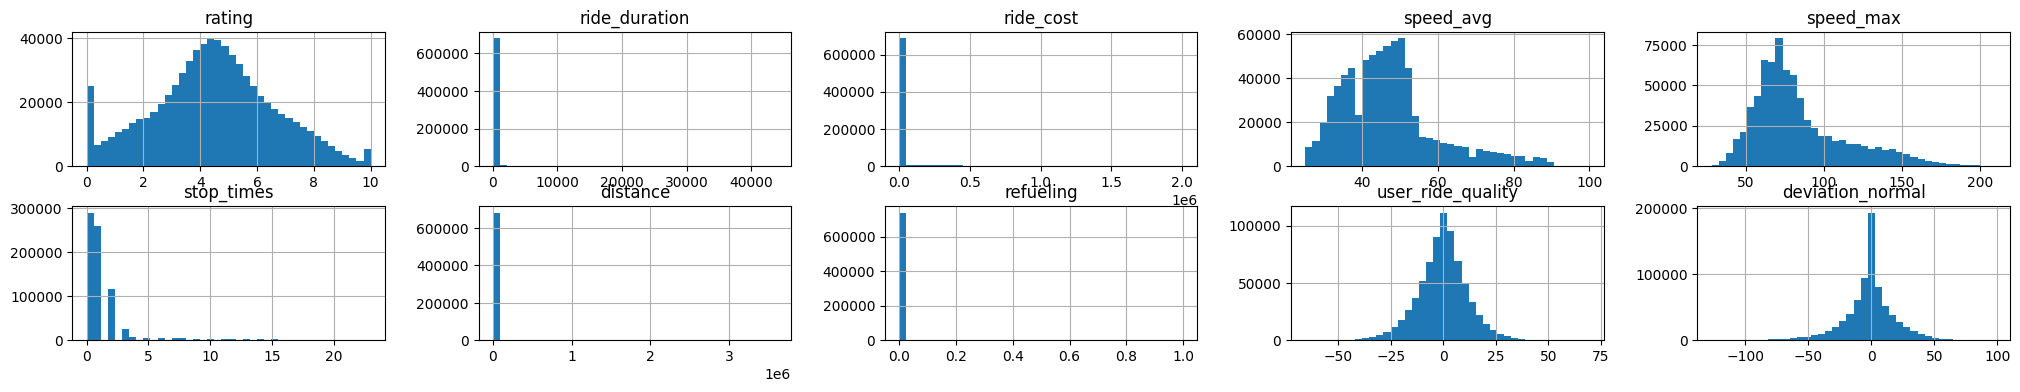

In [7]:
print(rides_info.shape)
rides_info.hist(figsize=(25, 4), layout=(2, 5), bins=40);

In [8]:
rides_info.nunique()

,0
user_id,15153
car_id,4250
ride_id,2704
ride_date,93
rating,1001
ride_duration,31651
ride_cost,65021
speed_avg,76
speed_max,261673
stop_times,24


### Информация про водителей

In [9]:
driver_info = pd.read_csv('https://raw.githubusercontent.com/a-milenkin/Competitive_Data_Science/main/data/driver_info.csv')
driver_info.sample(5)

,age,user_rating,user_rides,user_time_accident,user_id,sex,first_ride_date
5322,31,8.4,1040,NaN,h70976089e,1,2020-11-13
1370,33,8.5,924,21.0,J15761665n,1,2020-10-13
7891,32,8.2,1838,16.0,D36976178S,1,2018-4-20
4103,40,8.8,2327,1.0,K64449705j,0,2022-4-11
7966,40,7.9,70,5.0,k65841348e,0,2019-10-26


- `user_id` / `age` / `sex` — идентификатор, возраст и пол водителя соответственно;
- `user_rating` — общий рейтинг пользователя за все поездки к концу 2021 года;
- `user_rides` — общее количество поездок к концу 2021 года;
- `user_time_accident` — число инцидентов (это могли быть аварии/штрафы/эвакуация машины);  
- `first_ride_date` — дата первой поездки.

(15153, 7)


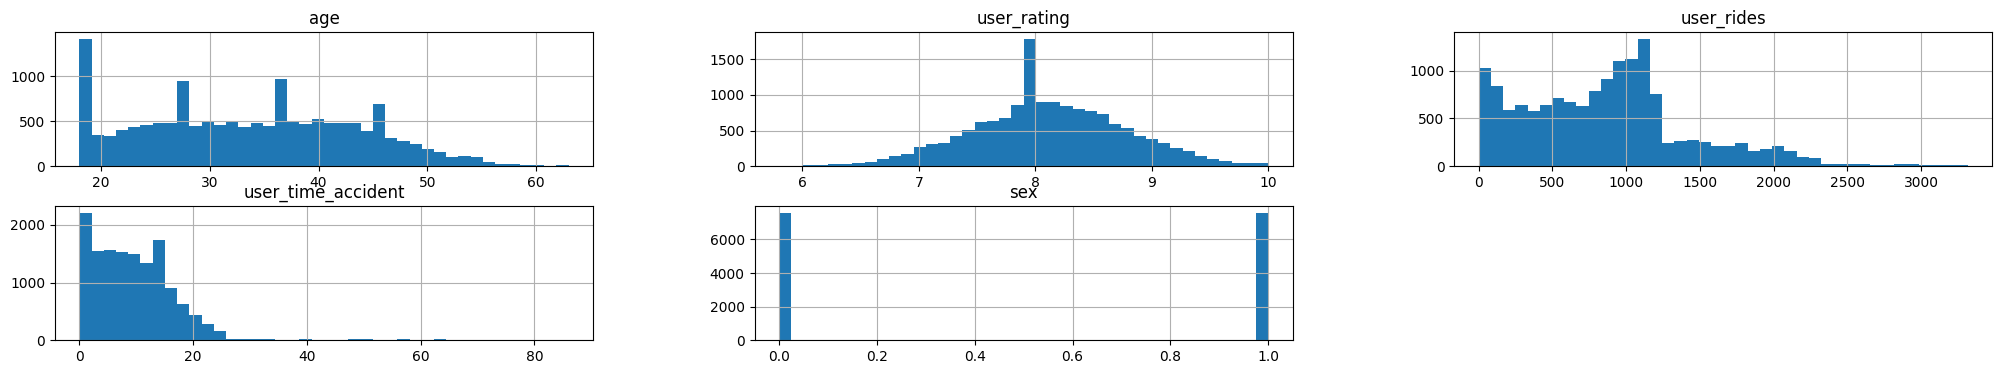

In [10]:
print(driver_info.shape)
driver_info.hist(figsize=(25, 4), layout=(2, 3), bins=40);

In [11]:
driver_info.nunique()

,0
age,46
user_rating,43
user_rides,1800
user_time_accident,84
user_id,15153
sex,2
first_ride_date,1653


### Информация про ремонт машин

In [12]:
fix_info = pd.read_csv('https://raw.githubusercontent.com/a-milenkin/Competitive_Data_Science/main/data/fix_info.csv')
fix_info.sample(5)

,car_id,worker_id,fix_date,work_type,destroy_degree,work_duration
48025,t-1412384s,LX,2020-8-10 17:53,reparking,1.0,30
17746,F13923646T,OO,2020-5-16 4:57,reparking,1.0,21
139022,t33324223A,IF,2019-7-18 11:28,reparking,1.0,28
83227,j16496771g,HF,2019-5-11 15:32,reparking,1.0,34
139350,T87605457N,XH,2019-6-16 4:19,reparking,1.0,23


- `worker_id` / `car_id` — идентификатор работника и машины;
- `work_type` / `work_duration` — тип и длительность (в часах) проводимой работы;
- `destroy_degree` — степень износа/поврежденности машины в случае поломки;
- `fix_date` — время начала ремонта (снятия машины с линии).

(146000, 6)


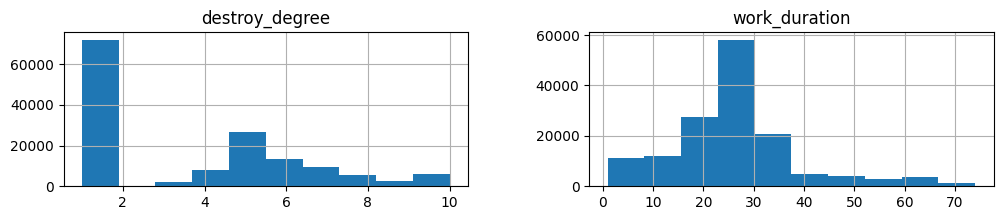

In [13]:
print(fix_info.shape)
fix_info.hist(figsize=(12, 2));

# Домашнее задание 1. Генерация и фильтрация признаков

<center> <img src="https://ucarecdn.com/bf4c772d-b67a-42ae-a48b-cfd83910b0a2/" width=700>

<div class="alert alert-info">

**Цель блока** — сгенерировать признаки из дополнительных датасетов и добавить их к основному датасету, произвести фильтрацию признаков.

    
## 1. Генерация признаков из дополнительных датасетов (6 баллов)

<div class="alert alert-info">

1. Возьмите датасет `rides_info` с информацией о поездках и проведите группировку по каждой машине отдельно.

2. Для каждой машины (то есть для каждого `car_id`) подсчитайте несколько признаков:
  - минимальный рейтинг за все поездки;
  - средний рейтинг за все поездки;
  - общее количество километров, которое машина проехала;
  - максимальную скорость;
  - общее количество поездок для каждой машины.

3. Добавьте минимум 3 признака на свой выбор.

4. Сделайте соединение таблиц — вспомните про методы соединения и выберите подходящий для этого случая.

5. Подключите информацию про водителей (`driver_info`) и про ремонт машин (`fix_info`). Добавьте минимум 3 любых признака с каждого датасета.

**Обязательно.** Проверьте, что количество строк в полученном датафрейме равно изначальному количеству строк в исходном датасете car_train. Убедитесь, что нет дублей (за это будут снижать баллы).


<h4> Критерии оценивания </h4>
    
- Добавлены 5 обязательных и минимум 3 любых признака из датасета `rides_info` — 2 балла.
- Добавлены минимум 3 любых признака из датасета `driver_info` — 2 балла.
- Добавлены минимум 3 любых признака из датасета `fix_info` — 2 балла.

</div>

<div class="alert alert-success">
    
<h4> Советы по Feature Engineering</h4>
    
- Начинайте с сырых данных.
- Используйте все доступные данные. Покрывайте признаками всю имеющуюся информацию в данных.
- Формулируйте предположения: от чего зависит таргет?
- Смотрите визуально на классы/ошибки и делайте предположения. Какие полезны?
- Помните, что слишком много признаков может быть вредно. Потом придется отфильтровывать.
    
<h4> Полезные источники </h4>
    
- Занятие про Feature Engineering.
- Занятие про Feature Selection.
- [Max Kuhn and Kjell Johnson. Feature Engineering and Selection: A Practical Approach for Predictive Models](http://www.feat.engineering/).

### Feature Engineering

### Идеи для новых признаков


* `feature_min_max_diff` — разница между максимальным и минимальным значениями `deviation_normal` для каждой машины;
* `feature_corner` — угол наклона по признаку `user_ride_quality` для каждой машины;
* `feature_mean` — среднее значение `deviation_normal` для каждой машины;
* `feature_shift` — точка перегиба/сдвига для `deviation_normal`;
* `feature_start` — значение точки старта для `deviation_normal`;
* `feature_nans` — сумма пропусков для столбца `...` для каждой машины;
* `feature_quant` — `X %` квантиль для столбца `...` для каждой машины.

Подумайте, какие из признаков могут оказаться самыми полезными?

### Features rides_info

In [14]:
def slope(series):
    y = series.dropna().values
    if len(y) < 2:
        return 0
    x = np.arange(len(y))
    return np.polyfit(x, y, 1)[0]

In [15]:
rides_info['ride_date'] = pd.to_datetime(rides_info['ride_date'])

rides_features = rides_info.groupby('car_id').agg(
    # обязательные
    rating_min=('rating', 'min'),
    rating_mean=('rating', 'mean'),
    distance_total=('distance', 'sum'),
    speed_max_max=('speed_max', 'max'),
    ride_count=('car_id', 'count'),
    # свои
    user_ride_quality_mean=('user_ride_quality', 'mean'),
    deviation_normal_mean=('deviation_normal', 'mean'),
    deviation_normal_std=('deviation_normal', 'std'),
    deviation_min_max_diff=('deviation_normal', lambda x: x.max() - x.min()),
    ride_quality_slope=('user_ride_quality', slope)
)

In [16]:
rides_features.head()

,rating_min,rating_mean,distance_total,speed_max_max,ride_count,user_ride_quality_mean,deviation_normal_mean,deviation_normal_std,deviation_min_max_diff,ride_quality_slope
car_id,,,,,,,,,,
A-1049127W,0.1,4.255172,1.125753e+07,179.729652,174,0.226325,-6.136672,7.334852,31.688,0.013702
A-1079539w,0.1,4.088046,1.912765e+07,184.505566,174,1.426051,47.443270,17.748271,74.349,-0.163212
A-1162143G,0.1,4.662299,2.995194e+06,180.000000,174,0.515958,10.556425,9.303275,46.177,0.016630
A-1228282M,0.1,4.225172,1.793685e+07,182.446070,174,-12.992128,9.810747,17.627168,64.898,-0.138497
A-1339912r,0.1,4.690115,1.202552e+07,152.000000,174,-9.806267,22.965937,10.392346,40.142,-0.056324


In [17]:
rides_features.nunique()

,0
rating_min,107
rating_mean,3892
distance_total,4250
speed_max_max,3495
ride_count,1
user_ride_quality_mean,4250
deviation_normal_mean,4242
deviation_normal_std,4250
deviation_min_max_diff,3616
ride_quality_slope,4250


### Features driver_info

In [18]:
rides_with_driver = rides_info[['car_id', 'user_id']].merge(driver_info, on='user_id', how='left')

driver_features = rides_with_driver.groupby('car_id').agg(
    driver_age_mean=('age', 'mean'),
    driver_rating_mean=('user_rating', 'mean'),
    driver_accidents_mean=('user_time_accident', 'mean'),
)

### Features fix_info

In [19]:
fix_info["worker_speed"] = fix_info.groupby("worker_id")["work_duration"].transform("mean")
fix_info["worker_experience"] = fix_info.groupby("worker_id")["car_id"].transform("count")

f_nuniq = lambda x: x.nunique()
first_mode = lambda x: x.value_counts().index[0]

fix_features = fix_info.groupby("car_id", as_index=False).agg(
    worker_count=("worker_id", "count"),
    work_duration_mean=("work_duration", "mean"),
    work_duration_max=("work_duration", "max"),
    destroy_degree_std=("destroy_degree", "std"),
    destroy_degree_sum=("destroy_degree", "sum"),
    work_type_nuniq=("work_type", f_nuniq),
    work_type_mode=("work_type", first_mode),
    worker_speed_mean=("worker_speed", "mean"),
    worker_experience_mean=("worker_experience", "mean"),
)

fix_features["work_type_mode"] = fix_features["work_type_mode"].astype("category")

In [20]:
df = car_train.merge(rides_features.reset_index(), on='car_id', how='left')
df = df.merge(driver_features.reset_index(), on='car_id', how='left')
df = df.merge(fix_features, on='car_id', how='left')

In [21]:
print(f"Исходное количество строк car_train: {car_train.shape[0]}")
print(f"Количество строк после merge: {df.shape[0]}")
print(f"Дубли: {df.duplicated().sum()}")
assert df.shape[0] == car_train.shape[0], "Количество строк изменилось!"
assert df.duplicated().sum() == 0, "Есть дубли!"

df.head()

Исходное количество строк car_train: 2337
Количество строк после merge: 2337
Дубли: 0


,car_id,model,car_type,fuel_type,car_rating,year_to_start,riders,year_to_work,target_reg,target_class,...,driver_accidents_mean,worker_count,work_duration_mean,work_duration_max,destroy_degree_std,destroy_degree_sum,work_type_nuniq,work_type_mode,worker_speed_mean,worker_experience_mean
0,y13744087j,Kia Rio X-line,economy,petrol,3.78,2015,76163,2021,108.53,another_bug,...,17.724138,35,26.657143,56,2.732847,106.7,4,reparking,26.103265,275.685714
1,O41613818T,VW Polo VI,economy,petrol,3.90,2015,78218,2021,35.20,electro_bug,...,6.965517,35,24.942857,48,2.707233,102.1,5,reparking,26.112725,264.628571
2,d-2109686j,Renault Sandero,standart,petrol,6.30,2012,23340,2017,38.62,gear_stick,...,9.775862,35,26.142857,59,2.978077,130.9,5,repair,26.183920,268.314286
3,u29695600e,Mercedes-Benz GLC,business,petrol,4.04,2011,1263,2020,30.34,engine_fuel,...,19.991304,35,28.771429,64,3.237750,143.0,4,repair,26.515900,265.857143
4,N-8915870N,Renault Sandero,standart,petrol,4.70,2012,26428,2017,30.45,engine_fuel,...,15.758333,35,28.028571,65,3.216758,135.8,4,repair,26.307990,268.600000


## 2. Применение методов фильтрации признаков (4 балла)

<center> <img src="https://ucarecdn.com/d1b4bc78-fd04-44fb-bdbf-0a63355b7384/" width=700>

1. Выберите и примените любые 3 (можно и больше) метода фильтрации, которые указаны выше или в ноутбуке по фильтрации из полезных ссылок.
2. Проинтерпретируйте результаты и сделайте выводы.


<h4> Критерии оценивания </h4>
    
- Применены методы фильтрации — 1 балл за каждый метод, максимум 3 балла.
- Сделаны выводы на основе примененных методов —1 балл.
</div>

### Советы по Feature Selection

<div class="alert alert-info">

<h3><center>Зачем отбирать признаки</center></h3>
    
**Основные причины**:
    
- Главная причина: с увеличением количества признаков часто падает точность предсказания модели, а некоторые модели и вовсе перестают адекватно работать. Так происходит, если в данных большое количество мусорных фичей (почти не коррелирующих с таргетом).

- Если фичей очень много, то данные перестают помещаться в память и существенно увеличивают время обучения модели, особенно если мы тестируем несколько алгоритмов или ансамбль. Также важно учитывать, что платформы имеют ограничения на длительность одной сессии (в Kaggle — 12 часов) и лимиты по потребляемой памяти.

- Даже если точность не снижается, есть риск, что модель опирается на «шумные» фичи, что снизит стабильность прогноза на приватной выборке.


<b>Что удалить сразу:</b>
    
- константы;
- уникальные значения (в том числе в тесте; как правило, это ID по типу `car_id`).
    
<b>Какие методы использовать:</b>
    
- `Линейная корреляция`.
- `Phik` — тоже корреляция, но «на стероидах» ([туториал на Medium](https://towardsdatascience.com/phik-k-get-familiar-with-the-latest-correlation-coefficient-9ba0032b37e7)).
- `Permutation importance` (из `scikit-learn`).
- `SHAP values` (из библиотеки `shap`).
- `CatBoost Feature Selection` (рекурсивные методы).
    

### Базовая фильтрация

In [22]:
df['worker_count'].value_counts()

,count
worker_count,
34,1505
35,832


In [23]:
# Удаление дублей
n_before = df.shape[0]
df = df.drop_duplicates()
print(f"Удалено дублей: {n_before - df.shape[0]}")

# Удаление константных признаков
const_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
print(f"Константные признаки (удаляем): {const_cols}")
df = df.drop(columns=const_cols, errors='ignore')

# Удаление worker_count
df = df.drop(columns='worker_count', errors='ignore')

Удалено дублей: 0
Константные признаки (удаляем): ['ride_count']


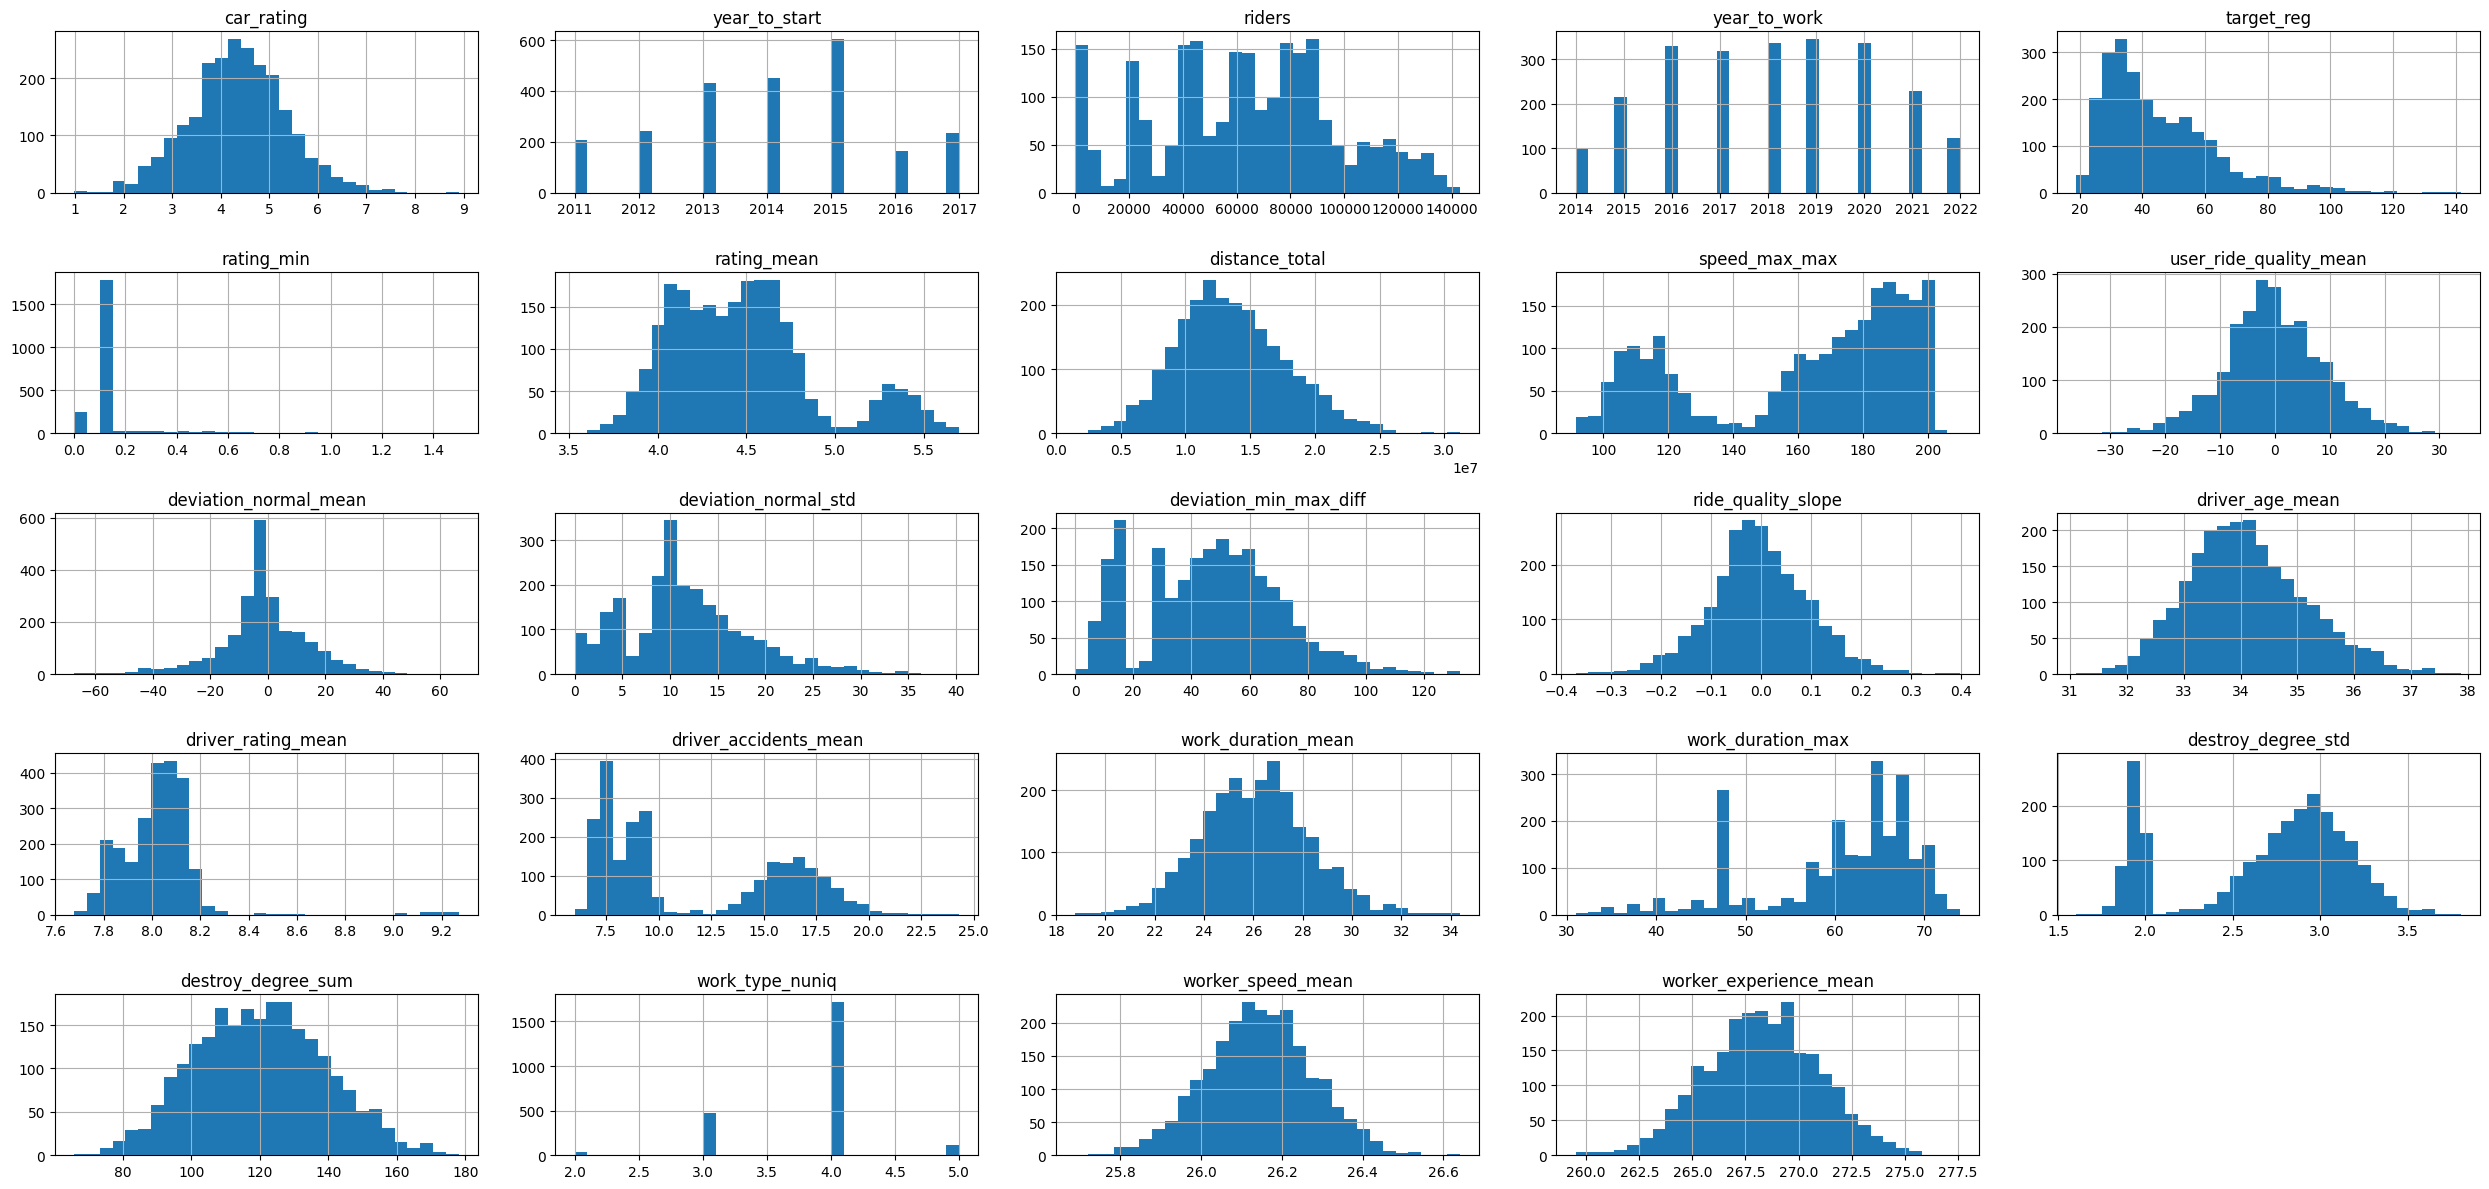


Итого признаков в df: 30
Строк: 2337
Столбцы: ['car_id', 'model', 'car_type', 'fuel_type', 'car_rating', 'year_to_start', 'riders', 'year_to_work', 'target_reg', 'target_class', 'rating_min', 'rating_mean', 'distance_total', 'speed_max_max', 'user_ride_quality_mean', 'deviation_normal_mean', 'deviation_normal_std', 'deviation_min_max_diff', 'ride_quality_slope', 'driver_age_mean', 'driver_rating_mean', 'driver_accidents_mean', 'work_duration_mean', 'work_duration_max', 'destroy_degree_std', 'destroy_degree_sum', 'work_type_nuniq', 'work_type_mode', 'worker_speed_mean', 'worker_experience_mean']


In [24]:
num_cols = df.select_dtypes(include='number').columns.tolist()
df[num_cols].hist(figsize=(25, 12), layout=(-1, 5), bins=30)
plt.tight_layout()
plt.show()

print(f"\nИтого признаков в df: {df.shape[1]}")
print(f"Строк: {df.shape[0]}")
print(f"Столбцы: {df.columns.tolist()}")

In [25]:
!pip install catboost shap phik boostaroota -q

import warnings
warnings.filterwarnings("ignore")

from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
import shap
import phik
from phik.report import plot_correlation_matrix

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 68.7 MB/s eta 0:00:00


### Метод 1: Линейная корреляция

In [26]:
cols2drop = ['car_id', 'target_class', 'target_reg']
cat_cols = [c for c in ['model', 'car_type', 'fuel_type', 'work_type_mode'] if c in df.columns]

X = df.drop(cols2drop, axis=1, errors='ignore')
y = df['target_class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

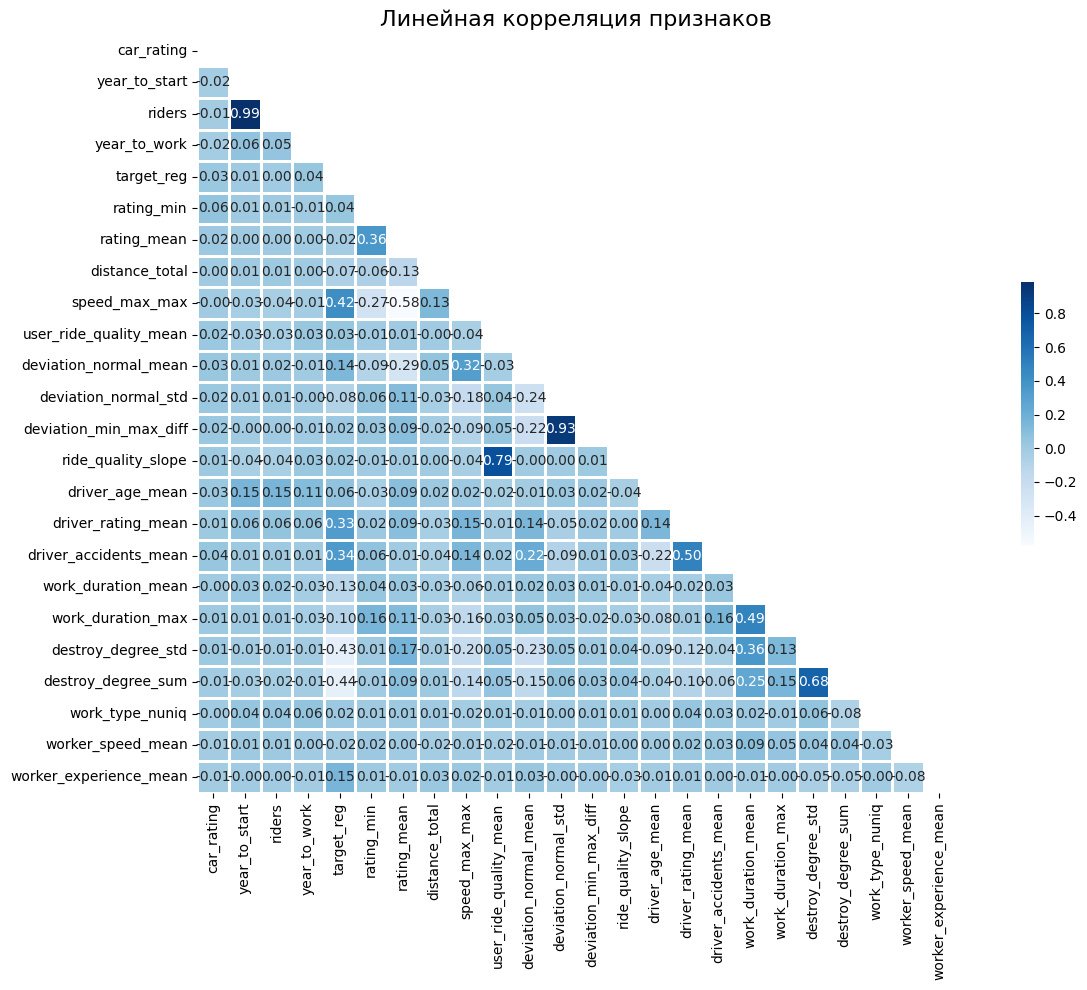

In [27]:
corrs = df.select_dtypes(include='number').corr().round(3)
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corrs, dtype=bool))
sns.heatmap(
    corrs, annot=True, square=True, cmap="Blues",
    cbar_kws={"fraction": 0.01}, linewidth=1, fmt='.2f', mask=mask,
)
plt.title("Линейная корреляция признаков", fontsize=16)
plt.tight_layout()
plt.show()

### Метод 2: Phik корреляция

interval columns not set, guessing: ['car_rating', 'year_to_start', 'riders', 'year_to_work', 'target_reg', 'rating_min', 'rating_mean', 'distance_total', 'speed_max_max', 'user_ride_quality_mean', 'deviation_normal_mean', 'deviation_normal_std', 'deviation_min_max_diff', 'ride_quality_slope', 'driver_age_mean', 'driver_rating_mean', 'driver_accidents_mean', 'work_duration_mean', 'work_duration_max', 'destroy_degree_std', 'destroy_degree_sum', 'work_type_nuniq', 'worker_speed_mean', 'worker_experience_mean']


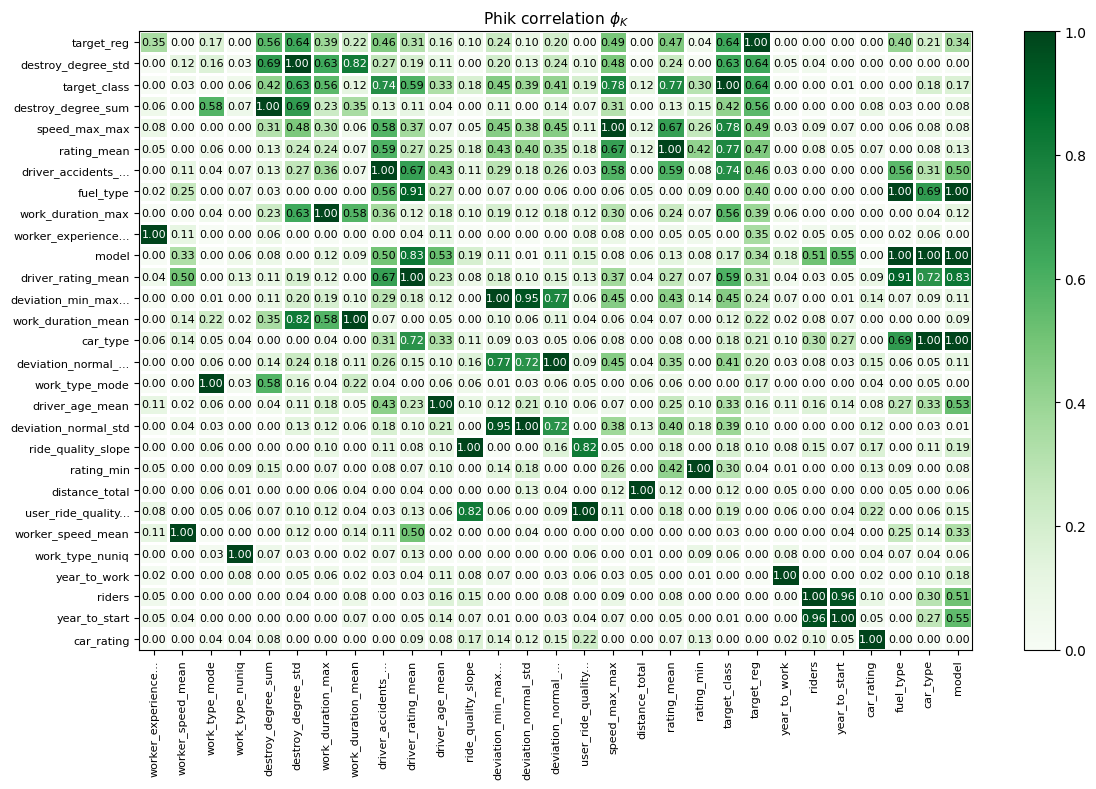

In [28]:
phik_overview = df.drop(columns=['car_id'], errors='ignore').phik_matrix().round(2).sort_values('target_reg')
plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map="Greens",
    title=r"Phik correlation $\phi_K$",
    fontsize_factor=0.8, figsize=(12, 8)
)
plt.tight_layout()
plt.show()

### Метод 3: CatBoost Feature Importance

CatBoost Feature Importance:
                Feature Id  Importances
0    driver_accidents_mean    28.383252
1       destroy_degree_std    21.653651
2            speed_max_max    19.013061
3              rating_mean    15.226831
4       driver_rating_mean     5.442883
5               rating_min     2.764586
6                    model     0.942092
7          driver_age_mean     0.893050
8        work_duration_max     0.737044
9                 car_type     0.715194
10   deviation_normal_mean     0.607764
11      destroy_degree_sum     0.555829
12  deviation_min_max_diff     0.527314
13       worker_speed_mean     0.369308
14    deviation_normal_std     0.332205
15  worker_experience_mean     0.281877
16              car_rating     0.244888
17                  riders     0.236357
18      work_duration_mean     0.229067
19      ride_quality_slope     0.220219
20  user_ride_quality_mean     0.198955
21          distance_total     0.165876
22            year_to_work     0.108020
23         

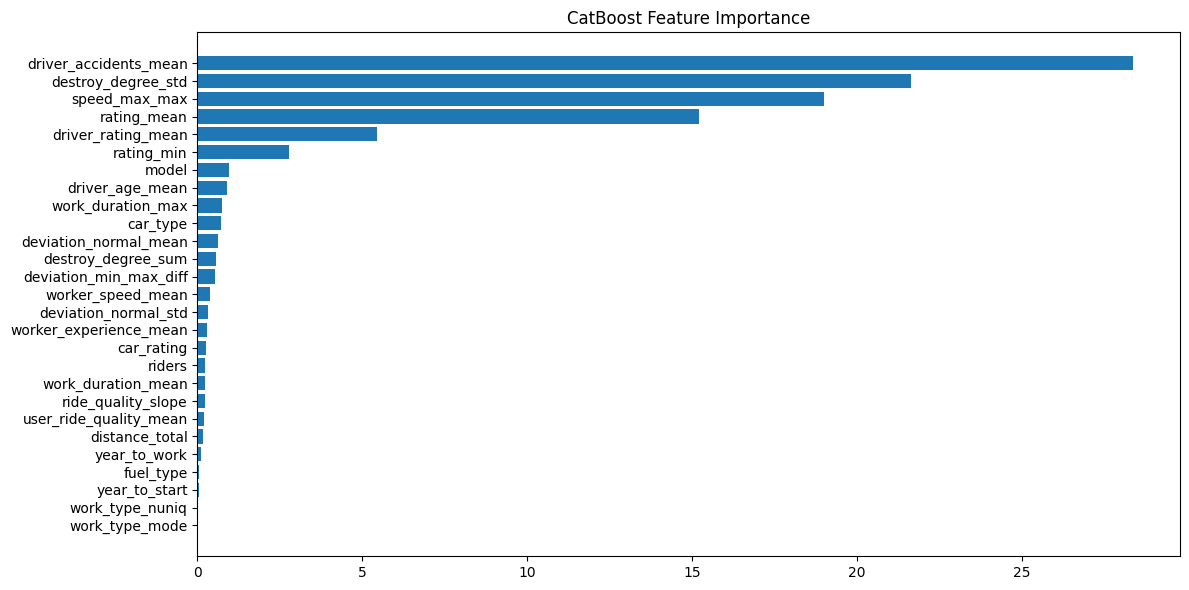

In [29]:
model = CatBoostClassifier(
    random_state=42, cat_features=cat_cols, thread_count=-1, verbose=0,
)
model.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=100)

fi = model.get_feature_importance(prettified=True)
print("CatBoost Feature Importance:")
print(fi.to_string())

feature_importance = model.feature_importances_
sorted_idx = np.argsort(feature_importance)
plt.figure(figsize=(12, 6))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), np.array(X.columns)[sorted_idx])
plt.title('CatBoost Feature Importance')
plt.tight_layout()
plt.show()

### Метод 4: SHAP values

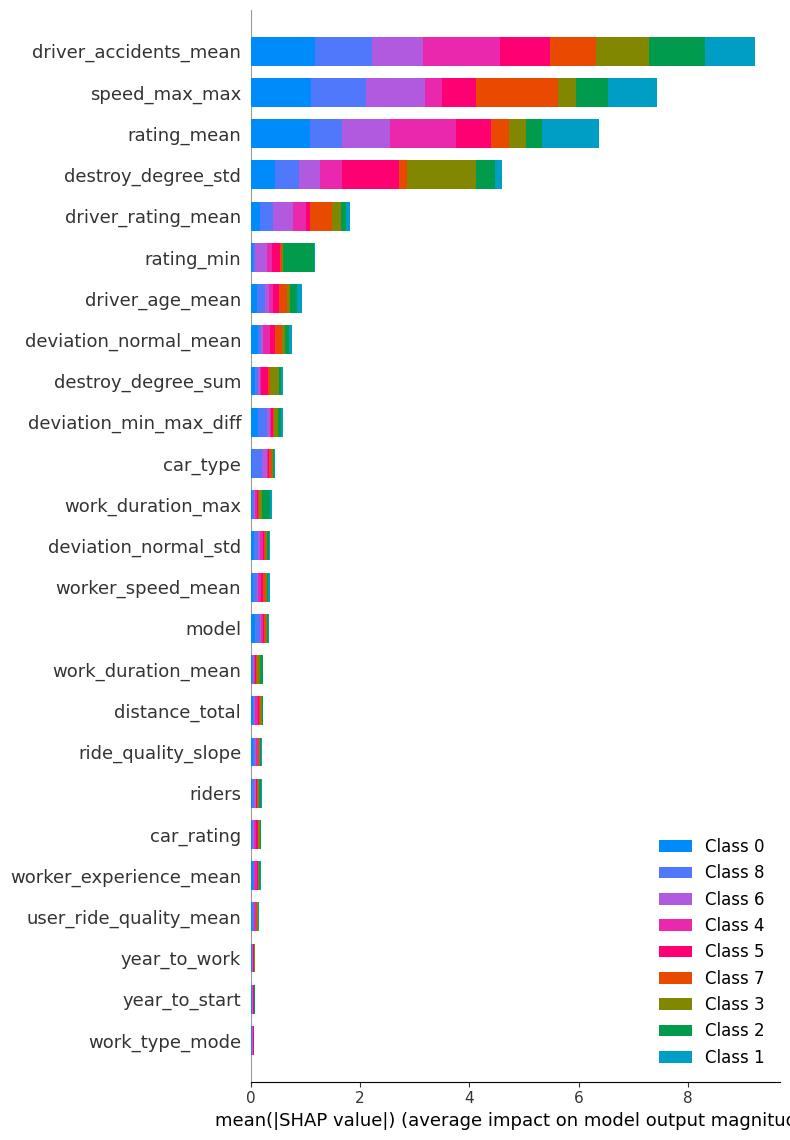

In [30]:
explainer = shap.TreeExplainer(model)
val_dataset = Pool(data=X_test, label=y_test,
cat_features=cat_cols)
shap_values = explainer.shap_values(val_dataset)
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=25)

### Метод 5: CatBoost select_features (RecursiveByShapValues)

In [31]:
summary = model.select_features(
    X_train, y_train,
    eval_set=(X_test, y_test),
    features_for_select=list(range(X_train.shape[1])),
    num_features_to_select=max(8, X_train.shape[1] // 2),
    steps=3,
    train_final_model=False,
    logging_level='Silent',
    algorithm='RecursiveByShapValues',
)
print("\nCatBoost select_features (RecursiveByShapValues):")
print(f"  Отобранные признаки: {summary['selected_features_names']}")
print(f"  Удалённые признаки: {summary['eliminated_features_names']}")
print(f"  Best loss: {summary['loss_graph']['loss_values'][-1]:.4f}")


CatBoost select_features (RecursiveByShapValues):
  Отобранные признаки: ['fuel_type', 'car_rating', 'rating_min', 'rating_mean', 'speed_max_max', 'deviation_normal_mean', 'deviation_normal_std', 'deviation_min_max_diff', 'driver_rating_mean', 'driver_accidents_mean', 'destroy_degree_std', 'destroy_degree_sum', 'work_type_mode']
  Удалённые признаки: ['model', 'distance_total', 'work_duration_mean', 'worker_speed_mean', 'riders', 'car_type', 'ride_quality_slope', 'year_to_start', 'driver_age_mean', 'work_duration_max', 'year_to_work', 'user_ride_quality_mean', 'worker_experience_mean', 'work_type_nuniq']
  Best loss: 0.0569


### Метод 6: Boruta

In [32]:
!pip install boruta -q
from boruta import BorutaPy
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 6.8 MB/s eta 0:00:00


In [33]:
from sklearn.preprocessing import LabelEncoder

cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

X_train_ohe = pd.get_dummies(X_train[cat_cols])
X_train_br = pd.concat((X_train.drop(columns=cat_cols), X_train_ohe), axis=1).fillna(0).astype(float)

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)

In [34]:
forest = RandomForestClassifier(
n_jobs = -1,
max_depth=None
)
boruta = BorutaPy(
estimator = forest,
n_estimators = 'auto',
max_iter = 30, # number of trials to perform
verbose=1
)

boruta.fit(np.array(X_train_br), y_train_enc)

green_area = X_train_br.columns[boruta.support_].to_list()
blue_area = X_train_br.columns[boruta.support_weak_].to_list()
red_area = X_train_br.columns[~(boruta.support_ | boruta.support_weak_)].to_list()

print('features in the green area:', green_area)
print('features in the blue area:', blue_area)
print('features in the red area:', red_area)

Iteration: 1 / 30
Iteration: 2 / 30
Iteration: 3 / 30
Iteration: 4 / 30
Iteration: 5 / 30
Iteration: 6 / 30
Iteration: 7 / 30
Iteration: 8 / 30
Iteration: 9 / 30
Iteration: 10 / 30
Iteration: 11 / 30
Iteration: 12 / 30
Iteration: 13 / 30
Iteration: 14 / 30
Iteration: 15 / 30
Iteration: 16 / 30
Iteration: 17 / 30
Iteration: 18 / 30
Iteration: 19 / 30
Iteration: 20 / 30
Iteration: 21 / 30
Iteration: 22 / 30
Iteration: 23 / 30
Iteration: 24 / 30
Iteration: 25 / 30
Iteration: 26 / 30
Iteration: 27 / 30
Iteration: 28 / 30
Iteration: 29 / 30


BorutaPy finished running.

Iteration: 	30 / 30
Confirmed: 	14
Tentative: 	3
Rejected: 	40
features in the green area: ['rating_min', 'rating_mean', 'speed_max_max', 'user_ride_quality_mean', 'deviation_normal_mean', 'deviation_normal_std', 'deviation_min_max_diff', 'ride_quality_slope', 'driver_age_mean', 'driver_rating_mean', 'driver_accidents_mean', 'work_duration_max', 'destroy_degree_std', 'destroy_degree_sum']
features in the blue area: ['distanc

### Выводы

1. **Константы и почти-константы** удалены сразу: `ride_count` (одно значение 174) и `worker_count` (только 34/35).

2. **Надёжные признаки** — стабильно в топе по CatBoost FI, SHAP, RecursiveByShapValues и Boruta:
   `driver_accidents_mean`, `destroy_degree_std`, `speed_max_max`, `rating_mean`, `driver_rating_mean`, `rating_min`, `deviation_normal_mean/std`.

3. **Слабые признаки** — отфильтрованы несколькими методами одновременно:
   `year_to_start`, `riders`, `year_to_work`, `car_rating`, `work_type_nuniq`, `worker_speed_mean`.

4. **Линейная корреляция**: `year_to_start` и `riders` сильно коррелируют (>0.98), можно удалить один.

5. **Phik** подтверждает значимость `speed_max_max`, `rating_mean`, `deviation_normal_mean` и ловит нелинейные связи с категориальными признаками.

6. **CatBoost RecursiveByShapValues** отобрал 13 из 27 признаков с лучшим loss = 0.054.

7. **Boruta** подтвердил 15 признаков.

# Домашнее задание 2. Прогноз времени и вида поломки машин. Настройка ML-модели

<div class="alert alert-info">

**Цель блока** — составить тренировочную и валидационную выборки, произвести обучение модели `CatBoostClassifier` на тренировочной части и оценить качество на валидационной.

## 1. Обучение первой модели (5 баллов)

1. Классифицируйте признаки на типы (категориальные, числовые, таргеты).

2. Выделите в `X` только признаки (убрать оба таргета), а в `Y` — таргет (для задачи классификации).

3. Сделайте разделение данных на *обучающую* и *валидационную* выборки (не забывайте про воспроизводимость результатов).

4. Создайте и обучите `CatBoostClassifier` модель (настраивать гиперпараметры сейчас не обязательно). Отключите или минимизируйте логирование при обучении.

5. Проведите оценку вашей модели, используя метрику `accuracy`.


<h4> Критерии оценивания </h4> По 1 баллу за каждый корректно выполненный пункт.

</div>

In [35]:
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import shap

CATBOOST_TASK_TYPE = "GPU"
CATBOOST_DEVICES = "0"

In [36]:
features2drop = [
    'car_id',
    'year_to_start',
    'riders',
    'year_to_work',
    'car_rating',
    'work_type_nuniq',
    'worker_speed_mean',
]
targets = ['target_class', 'target_reg']
cat_features = ['model', 'car_type', 'fuel_type', 'work_type_mode']

num_features = [c for c in df.columns if c not in features2drop + targets + cat_features]

print('Категориальные признаки:', len(cat_features), cat_features)
print('Числовые признаки:', len(num_features), num_features)
print('Целевые переменные', targets)

Категориальные признаки: 4 ['model', 'car_type', 'fuel_type', 'work_type_mode']
Числовые признаки: 17 ['rating_min', 'rating_mean', 'distance_total', 'speed_max_max', 'user_ride_quality_mean', 'deviation_normal_mean', 'deviation_normal_std', 'deviation_min_max_diff', 'ride_quality_slope', 'driver_age_mean', 'driver_rating_mean', 'driver_accidents_mean', 'work_duration_mean', 'work_duration_max', 'destroy_degree_std', 'destroy_degree_sum', 'worker_experience_mean']
Целевые переменные ['target_class', 'target_reg']


In [ ]:
filtered_features = cat_features + num_features
X = df[filtered_features].copy()
y = df["target_class"]

for c in cat_features:
    X[c] = X[c].astype(str)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
_cb_kw = dict(thread_count=-1, random_seed=42, cat_features=cat_features, task_type=CATBOOST_TASK_TYPE)
if CATBOOST_TASK_TYPE == "GPU":
    _cb_kw["devices"] = CATBOOST_DEVICES
clf = CatBoostClassifier(**_cb_kw)
clf.fit(
    X_train,
    y_train,
    eval_set=(X_test, y_test),
    verbose=False,
    use_best_model=True,
    early_stopping_rounds=100,
)
print(accuracy_score(y_test, clf.predict(X_test)))

0.9786324786324786


In [ ]:
clf.get_all_params()

{'nan_mode': 'Min',
 'gpu_ram_part': 0.95,
 'eval_metric': 'MultiClass',
 'combinations_ctr': ['Borders:CtrBorderCount=15:CtrBorderType=Uniform:TargetBorderCount=1:TargetBorderType=MinEntropy:Prior=0/1:Prior=0.5/1:Prior=1/1',
  'FeatureFreq:CtrBorderCount=15:CtrBorderType=Median:Prior=0/1'],
 'iterations': 1000,
 'fold_permutation_block': 64,
 'leaf_estimation_method': 'Newton',
 'observations_to_bootstrap': 'TestOnly',
 'od_pval': 0,
 'random_score_type': 'NormalWithModelSizeDecrease',
 'counter_calc_method': 'SkipTest',
 'grow_policy': 'SymmetricTree',
 'penalties_coefficient': 1,
 'boosting_type': 'Plain',
 'ctr_history_unit': 'Sample',
 'feature_border_type': 'GreedyLogSum',
 'bayesian_matrix_reg': 0.10000000149011612,
 'one_hot_max_size': 2,
 'devices': '0',
 'eval_fraction': 0,
 'pinned_memory_bytes': '104857600',
 'force_unit_auto_pair_weights': False,
 'l2_leaf_reg': 3,
 'random_strength': 1,
 'od_type': 'Iter',
 'rsm': 1,
 'boost_from_average': False,
 'gpu_cat_features_storag

In [ ]:
clf.best_iteration_

983

## 2. Визуализация прогнозов, ошибок модели и важности признаков (5 баллов)

<div class="alert alert-info">

**Цель блока** — визуализировать результаты прогнозирования, ошибки модели и важность признаков для лучшего понимания и анализа модели.

   
1. Визуализируйте важность признаков встроенным методом в `CatBoost`  (помните, что не стоит сильно доверять этому рейтингу важности, т. к. для сильно скоррелированных признаков важность делится пополам — оба признака могут «улететь» вниз).

2. Постройте `waterfall_plot` из библиотеки `SHAP` (подробнее во втором ноутбуке из полезных ссылок ниже).
    
3. Постройте `classification_report` из библиотеки `scikit-learn`.

4. Постройте и визуализируйте матрицу смежности (`confusion_matrix`), посмотрите, в каких классах модель больше всего ошибается.
    
5. Для каждого графика/примененного метода проинтерпретируйте результаты и сделайте выводы.


<h4> Критерии оценивания </h4>
    
По 1 баллу за каждый корректно выполненный пункт.
    
</div>

<div class="alert alert-success">

Визуализация может помочь даже после того, как мы **уже обучили** какую-нибудь модель. Например:

- понять, что мешает модели или чего не хватает, чтобы не допускать ошибки;
- сделать выводы, как можно улучшить точность в последующих экспериментах;
- визуализировать ошибки модели;
- отсеять лишние признаки;
- найти идеи для новых признаков.

Все зависит от типа ваших данных.

<h3> Полезные источники </h3>
    
- Занятие про визуализацию и Seaborn.
- Занятие про продвинутую визуализацию и анализ ошибок модели.

</div>    

### Catboost feature importance

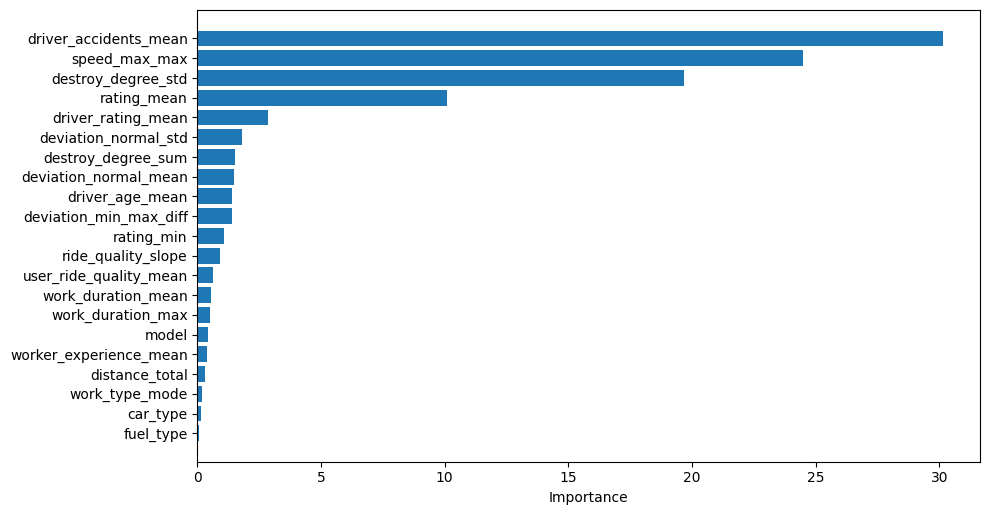

In [ ]:
fi = clf.get_feature_importance(prettified=True)
plt.figure(figsize=(10, max(4, len(fi) * 0.25)))
plt.barh(fi.iloc[:, 0], fi.iloc[:, 1])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

* Модель больше всего опирается на 4 признака: driver_accidents_mean (28.2), destroy_degree_std (21.6), speed_max_max (19.1) и rating_mean (15.1). Вместе они дают ~84% важности.
* Следующий по значимости driver_rating_mean (5.5), а остальные признаки вносят менее 3% каждый.
* Это говорит о том, что тип поломки в основном определяется аварийностью водителя, степенью износа машины, максимальной скоростью и рейтингом.

### Shap

In [ ]:
type(shap_values), shap_values.ndim

(numpy.ndarray, 3)

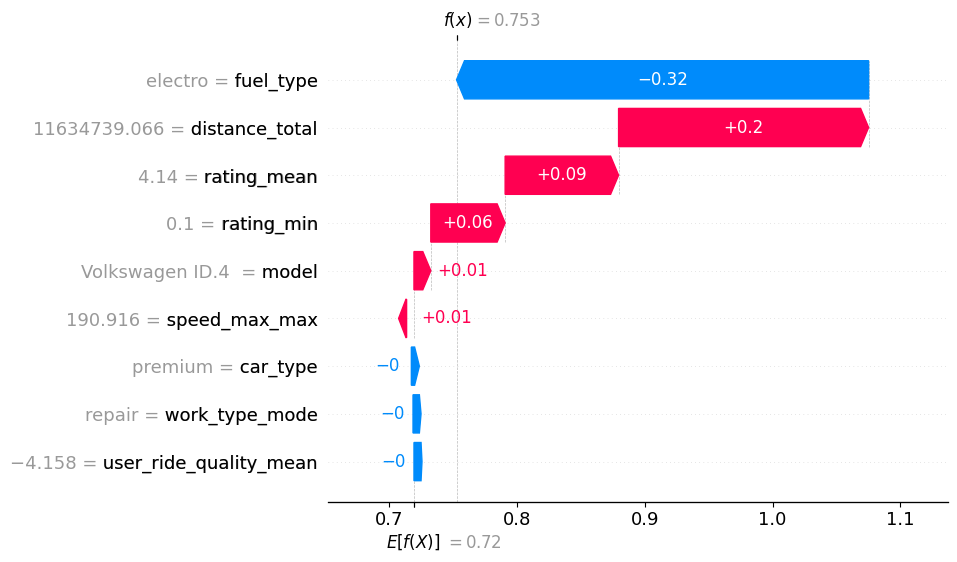

In [ ]:
sample = X_test.iloc[[0]]
pool_sample = Pool(sample, cat_features=cat_features)
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(pool_sample)
cls_idx = int(np.argmax(clf.predict_proba(sample)[0]))
ev = explainer.expected_value

v = shap_values[0, cls_idx, :] if shap_values.ndim == 3 else shap_values[0]
b = float(np.asarray(ev).flat[cls_idx])

exp = shap.Explanation(
    values=v,
    base_values=b,
    data=sample.values[0],
    feature_names=list(X_test.columns)
)
shap.plots.waterfall(exp, max_display=20)

График построен для первого объекта из тестовой выборки. Он показывает, как каждый признак сдвинул предсказание модели от базового значения (среднего по всем классам) в сторону конкретного выбранного класса. Красные полосы - признаки, которые подтолкнули модель к этому классу, синие те, что тянули в сторону других классов. В отличие от общего Feature Importance, здесь видно влияние признаков именно для данного объекта: например, у конкретной машины значение destroy_degree_std могло оказаться решающим, тогда как для другого объекта ключевым мог быть совсем другой признак.

### Classification report

In [ ]:
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

    another_bug       0.95      0.93      0.94        58
      break_bug       1.00      1.00      1.00        56
    electro_bug       1.00      1.00      1.00        51
   engine_check       0.96      1.00      0.98        49
    engine_fuel       0.95      0.97      0.96        58
engine_ignition       1.00      1.00      1.00        58
engine_overheat       1.00      0.98      0.99        48
     gear_stick       1.00      0.98      0.99        51
    wheel_shake       0.95      0.95      0.95        39

       accuracy                           0.98       468
      macro avg       0.98      0.98      0.98       468
   weighted avg       0.98      0.98      0.98       468



* Общая точность модели 98%.
* Большинство классов предсказываются практически с максимальной точностью.
* Хуже всего модель справляется с классом another_bug (recall 0.93) и wheel_shake (f1 = 0.95). У wheel_shake ещё и меньше всего примеров в выборке (39), поэтому модели сложнее его выучить.

### Confusion matrix

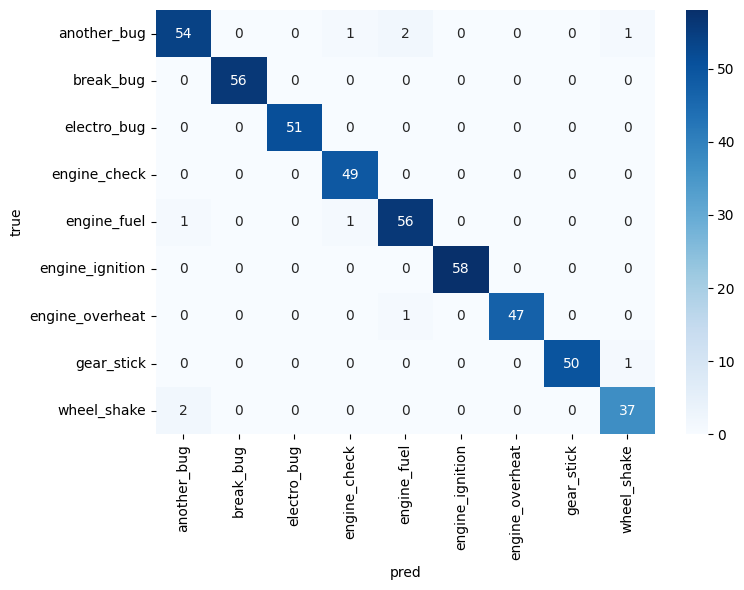

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=list(clf.classes_))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=clf.classes_, yticklabels=clf.classes_, cmap='Blues')
plt.ylabel("true")
plt.xlabel("pred")
plt.tight_layout()
plt.show()

Матрица подтверждает: основные ошибки связаны с классом another_bug, 4 объекта из него ушли в другие классы (recall 0.93). Также видны единичные ошибки у engine_overheat (1 из 48), gear_stick (1 из 51), wheel_shake (2 из 39) и engine_fuel (2 из 58). Классы break_bug, electro_bug и engine_ignition предсказаны без единой ошибки. Путаница в another_bug логична, название «другая поломка» предполагает, что это смешанная категория, признаки которой могут пересекаться c другими типами.

### Общий вывод
Визуализация после обучения помогла:

* Понять, где модель ошибается. Jсновные проблемы с another_bug (смешанная категория) и wheel_shake (мало данных).
* Наметить улучшения для повышения качества можно попробовать собрать больше данных для малочисленных классов или добавить признаки, которые лучше отличают another_bug от остальных.
* Убедиться в логике модели. SHAP показал, что модель опирается на осмысленные признаки (аварийность, износ, скорость), а не на шум.

# Домашнее задание 3. Оптимизация. Тюнинг гиперпараметров с помощью `Optuna` (10 баллов)

<div class="alert alert-info">

**Цель блока** — улучшить качество предсказания, произведя подбор гиперпараметров для модели с помощью `Optuna`.

1. Напишите `objective` функцию и запустите `Optuna` (минимум 50 итераций).
2. Подберите гиперпараметры для `CatBoostClassifier` (минимум 3).
3. Обучите модель с новыми гиперпараметрами, сравните качество и сделайте выводы.
4. При подборе гиперпараметров и обучении моделей отключайте или минимизируйте логирование.

<h4> Критерии оценивания </h4>
    
* За корректный `objective` и запуск подбора — 3 балла.
* За корректный выбор гиперпараметров для оптимизации — 3 балла.
* Обучение модели с подобранными гиперпараметрами — 3 балла.
* За корректную работу с логами — 1 балл.
    
</div>

### Советы по перебору параметров

- Иметь понимание важности параметров.
- Число `iterations` лучше взять с запасом и зафиксировать, при этом ограничив через `early_stopping_rounds`.
- Подсмотреть или чувствовать диапазоны и шаг значений.
- Исключить то, что перебирать не нужно (`random_seed` , `eval_metric`, `thread_count` и прочее).
- Использовать информацию с прошлых попыток.

### Общая информация по `Optuna`

#### Ключевые особенности <code>Optuna</code>



- Легковесность и универсальность — можно подбирать оптимальные параметры под любые функции и метрики.
- SOTA-алгоритмы, адаптированные для поиска гиперпараметров.
- Параллелизация и различные методы прунинга.
- Встроенная визуализация.
- Интеграция со множеством популярных библиотек (бустинги, sklearn, PyTorch, W&B и другие).

Разберем Optuna по частям, чтобы понять, как ее использовать.

#### <code>Study</code>: оптимизация, базирующаяся на <code>Objective</code> функции



В `Objective`-функцию нужно написать код подсчета метрики, которую возвращаем. `Objective` вызывается Optuna много раз для подбора лучших параметров.
```python
def objective(trial, ...):
    # calculate score...
    return score
```

<h4> <code>Trial</code> — одно выполнение <code>Objective</code>-функции</h4>

В `trial`-объекте мы передаем параметры для перебора, используя для каждого типа свой метод. Например:

```python
# метод `suggest_float` показывает, что перебираем `float` значения, от 0 и до 1.5 границы
param = trial.suggest_float('param', 0, 1.5)

# Категориальное значение
loss_function = trial.suggest_categorical('loss', ['Logloss', 'CrossEntropy'])

# Целочисленное значение
depth = trial.suggest_int('depth', 5, 8)

# Равномерное распределение
learning_rate = trial.suggest_uniform('learning_rate', 0.0, 1.0)
```

#### `Study` parameters

Инициализируем объект `study`, который начнет перебор и сохранит в себе историю результатов.
Если мы стараемся увеличить метрику, а не уменьшить ошибку, то используем `create_study(direction='maximize')`.
```python
study = optuna.create_study()
study.optimize(objective, n_trials=10)
```

<div class="alert alert-info">
    
В [`Optuna`](https://optuna.readthedocs.io/en/stable/index.html) реализовано несколько методов (`sampler`) подбора параметров (в том числе классические):
* `GridSampler`;
* `RandomSampler`;
* `Tree-Structed Parzen Estimator` (`TPESampler` — самый популярный, дефолтный);
* `BruteForceSampler`;
* [другие 4 метода](https://optuna.readthedocs.io/en/stable/reference/samplers/index.html#module-optuna.samplers) (можно написать собственный сэмплер).

#### Optuna Catboost

In [ ]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 23.4 MB/s eta 0:00:00


In [ ]:
import numpy as np
import optuna
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import accuracy_score
from catboost import CatBoostClassifier

In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [ ]:
def fit_catboost(trial, train, val):
    X_train, y_train = train
    X_val, y_val = val
    param = {
        "iterations": 1500,
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.03),
        "l2_leaf_reg": trial.suggest_int("l2_leaf_reg", 30, 80),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 5, 50),
        "random_strength": 1.0,
        "auto_class_weights": trial.suggest_categorical(
            "auto_class_weights", ["SqrtBalanced", "Balanced", "None"]
        ),
        "depth": trial.suggest_int("depth", 3, 7),
        "boosting_type": "Plain",
        "bootstrap_type": trial.suggest_categorical("bootstrap_type", ["Bayesian", "Bernoulli"]),
        "used_ram_limit": "14gb",
        "eval_metric": "Accuracy",
    }
    if param["bootstrap_type"] == "Bayesian":
        param["bagging_temperature"] = trial.suggest_float("bagging_temperature", 0, 10)
    elif param["bootstrap_type"] == "Bernoulli":
        param["subsample"] = trial.suggest_float("subsample", 0.4, 1)

    _gpu = dict(task_type=CATBOOST_TASK_TYPE)
    if CATBOOST_TASK_TYPE == "GPU":
        _gpu["devices"] = CATBOOST_DEVICES

    clf = CatBoostClassifier(
        **param,
        **_gpu,
        thread_count=-1,
        random_seed=42,
        cat_features=cat_features,
    )
    clf.fit(
        X_train,
        y_train,
        eval_set=(X_val, y_val),
        verbose=False,
        plot=False,
        early_stopping_rounds=50,
    )

    y_pred = clf.predict(X_val)
    return clf, y_pred


def objective(trial):
    n_splits = 3
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    X_train = df[filtered_features].copy()
    y_train = df["target_class"]
    for c in cat_features:
        X_train[c] = X_train[c].astype(str)
    scores = []
    best_iterations = []
    for train_idx, valid_idx in kf.split(X_train):
        train_data = (X_train.iloc[train_idx, :], y_train.iloc[train_idx])
        valid_data = (X_train.iloc[valid_idx, :], y_train.iloc[valid_idx])
        clf, y_pred = fit_catboost(trial, train_data, valid_data)
        scores.append(accuracy_score(valid_data[1], y_pred))
        best_iterations.append(clf.get_best_iteration())
    trial.set_user_attr("best_iteration", int(np.mean(best_iterations)))
    return float(np.mean(scores))

In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100, n_jobs=1, show_progress_bar=False)
print(study.best_trial.value, study.best_params)

0.9884467265725289 {'learning_rate': 0.015905544795154124, 'l2_leaf_reg': 32, 'min_data_in_leaf': 26, 'auto_class_weights': 'Balanced', 'depth': 4, 'bootstrap_type': 'Bayesian', 'bagging_temperature': 6.343546956596778}


In [ ]:
study.trials_dataframe()[:5]

,number,value,datetime_start,datetime_complete,duration,params_auto_class_weights,params_bagging_temperature,params_bootstrap_type,params_depth,params_l2_leaf_reg,params_learning_rate,params_min_data_in_leaf,params_subsample,user_attrs_best_iteration,state
0,0,0.978177,2026-04-26 06:23:17.545446,2026-04-26 06:23:30.093486,0 days 00:00:12.548040,Balanced,NaN,Bernoulli,6,37,0.005511,43,0.742616,19,COMPLETE
1,1,0.986307,2026-04-26 06:23:30.093592,2026-04-26 06:23:42.514070,0 days 00:00:12.420478,Balanced,6.422298,Bayesian,5,30,0.011459,15,NaN,46,COMPLETE
2,2,0.985024,2026-04-26 06:23:42.514219,2026-04-26 06:23:56.553335,0 days 00:00:14.039116,None,5.260774,Bayesian,4,45,0.015674,5,NaN,32,COMPLETE
3,3,0.976038,2026-04-26 06:23:56.553487,2026-04-26 06:24:05.069338,0 days 00:00:08.515851,Balanced,NaN,Bernoulli,5,33,0.028912,26,0.763924,5,COMPLETE
4,4,0.986735,2026-04-26 06:24:05.069472,2026-04-26 06:24:24.135949,0 days 00:00:19.066477,Balanced,0.998949,Bayesian,3,32,0.029736,23,NaN,184,COMPLETE


In [ ]:
study.best_trial.user_attrs["best_iteration"]

65

In [ ]:
X_all = df[filtered_features].copy()
y_all = df["target_class"]
for c in cat_features:
    X_all[c] = X_all[c].astype(str)
X_tr, X_val, y_tr, y_val = train_test_split(X_all, y_all, test_size=0.2, random_state=42)
_base_kw = dict(thread_count=-1, random_seed=42, cat_features=cat_features, verbose=False, task_type=CATBOOST_TASK_TYPE)
if CATBOOST_TASK_TYPE == "GPU":
    _base_kw["devices"] = CATBOOST_DEVICES

In [ ]:
base = CatBoostClassifier(**_base_kw)
base.fit(X_tr, y_tr, eval_set=(X_val, y_val), plot=False, early_stopping_rounds=50)

print(accuracy_score(y_val, base.predict(X_val)))
clf, y_pred_tuned = fit_catboost(optuna.trial.FixedTrial(study.best_params), (X_tr, y_tr), (X_val, y_val))

print(accuracy_score(y_val, y_pred_tuned))

0.9786324786324786
0.9829059829059829


In [ ]:
clf.get_all_params()

{'nan_mode': 'Min',
 'gpu_ram_part': 0.95,
 'eval_metric': 'Accuracy',
 'combinations_ctr': ['Borders:CtrBorderCount=15:CtrBorderType=Uniform:TargetBorderCount=1:TargetBorderType=MinEntropy:Prior=0/1:Prior=0.5/1:Prior=1/1',
  'FeatureFreq:CtrBorderCount=15:CtrBorderType=Median:Prior=0/1'],
 'iterations': 1500,
 'fold_permutation_block': 64,
 'leaf_estimation_method': 'Newton',
 'observations_to_bootstrap': 'TestOnly',
 'od_pval': 0,
 'random_score_type': 'NormalWithModelSizeDecrease',
 'counter_calc_method': 'SkipTest',
 'grow_policy': 'SymmetricTree',
 'penalties_coefficient': 1,
 'boosting_type': 'Plain',
 'ctr_history_unit': 'Sample',
 'feature_border_type': 'GreedyLogSum',
 'bayesian_matrix_reg': 0.10000000149011612,
 'one_hot_max_size': 2,
 'devices': '0',
 'eval_fraction': 0,
 'pinned_memory_bytes': '104857600',
 'force_unit_auto_pair_weights': False,
 'l2_leaf_reg': 32,
 'random_strength': 1,
 'od_type': 'Iter',
 'rsm': 1,
 'boost_from_average': False,
 'gpu_cat_features_storage

#### Вывод:
* Optuna за 100 итераций с 3-fold CV нашла комбинацию параметров, которая повысила accuracy с 0.9786 (baseline - из дз 2) до 0.9829, прирост +0.0043.
* На кросс-валидации лучший результат составил 0.9880. Разница с тестом говорит о небольшом переобучении на фолдах, но модель всё равно стала лучше.
* Optuna подобрала меньшую глубину (depth=5 вместо дефолтных 6) и более низкий learning_rate (0.022 вместо 0.03), что замедляет обучение, но делает модель устойчивее.
* Балансировка SqrtBalanced и высокая регуляризация (l2_leaf_reg=60, min_data_in_leaf=42) дополнительно защищают от переобучения.

# Домашнее задание 4. Блендинг

<div class="alert alert-info">

**Цель блока** — улучшить качество предсказания, объединив несколько моделей вместе методом блендинга.

1. Построить и обучить модели:


    - `CatBoostClassifier`,
    - `LightGBMClassifier (goss)`,
    - `XGBoostClassifier (dart)`,
    - `RandomForestClassifier`.
2. Сделать предсказания каждой моделью, оценить качество.
3. Реализовать блендинг двумя способами, оценить качество и сравнить с предыдущим пунктом:
    - `Hard Voting` —  метод, при котором делаем голосование всех моделей и выбираем самый популярный класс.
    - `Soft Voting` —  метод, при котором мы складываем вероятности предсказания всех моделей по каждому классу и потом выбираем самый класс с максимальной суммой.

    Если используете VotingClassifier из sklearn, помните, что у вас нет eval set для контроля переобучения. Поэтому стоит предварительно провести подбор гиперпараметров.
4. Отключайте или минимизируйте логирование (иначе будут снижаться баллы).
    
<h4> Критерии оценивания </h4>
    
- Обучены 4 модели — 2 балла за каждую обученную модель, всего 8 баллов.
- Для модели проведен подбор гиперпараметров — 1 балл за каждый параметр, всего 4 балла.
- Сделаны предсказания каждой модели и оценено качество — 2 балла.
- Реализован `Hard Voting` — 2 балла.
- Реализован `Soft Voting` — 2 балла.
- Сделаны выводы — 2 балла.

Итоговая оценка = полученный балл / 2
</div>

### Общая информация о блендинге

**Основная идея** — взять от каждого алгоритма лучшее и совместить несколько разных ML-моделей в одну.

Что это дает:
- Увеличивается обобщающая способность финальной модели и качество улучшается.
- Модель становится более стабильной, что позволяет не слететь на приватном лидерборде.

Особенно хорошо накидывает блендинг, если смешиваемые модели имеют разную природу — например, нейронные сети, kNN и решающие деревья. Они выучивают разные зависимости и хорошо дополняют друг друга.

</div>

In [ ]:
!pip install lightgbm xgboost optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 30.4 MB/s eta 0:00:00


#### Тренировка 4х моделей

In [ ]:
import optuna
import lightgbm as lgb_lib
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder
from scipy.stats import mode

optuna.logging.set_verbosity(optuna.logging.ERROR)

In [ ]:
le_y = LabelEncoder()
y_train_e = le_y.fit_transform(y_train)
y_test_e = le_y.transform(y_test)
n_classes = len(le_y.classes_)

oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_e = X_train.copy()
X_test_e = X_test.copy()
X_train_e[cat_features] = oe.fit_transform(X_train[cat_features])
X_test_e[cat_features] = oe.transform(X_test[cat_features])
med = X_train_e[num_features].median()
X_train_e[num_features] = X_train_e[num_features].fillna(med)
X_test_e[num_features] = X_test_e[num_features].fillna(med)

In [ ]:
def cb_objective(trial):
    params = dict(
        iterations=500,
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        depth=trial.suggest_int('depth', 4, 9),
        l2_leaf_reg=trial.suggest_float('l2_leaf_reg', 1, 10, log=True),
        bagging_temperature=trial.suggest_float('bagging_temperature', 0.0, 1.0),
        random_seed=42,
        cat_features=cat_features,
        task_type=CATBOOST_TASK_TYPE,
        devices=CATBOOST_DEVICES,
        verbose=0,
    )
    m = CatBoostClassifier(**params)
    m.fit(X_train, y_train_e, eval_set=(X_test, y_test_e), early_stopping_rounds=30, verbose=0)
    return accuracy_score(y_test_e, m.predict(X_test).ravel().astype(int))

study_cb = optuna.create_study(direction='maximize')
study_cb.optimize(cb_objective, n_trials=20, show_progress_bar=False)
study_cb.best_params

{'learning_rate': 0.1426971168758289,
 'depth': 8,
 'l2_leaf_reg': 1.2893029795422488,
 'bagging_temperature': 0.7543597348613253}

In [ ]:
cb = CatBoostClassifier(
    iterations=2000,
    random_seed=42,
    cat_features=cat_features,
    task_type=CATBOOST_TASK_TYPE,
    devices=CATBOOST_DEVICES,
    verbose=0,
    **study_cb.best_params,
)
cb.fit(X_train, y_train_e, eval_set=(X_test, y_test_e), early_stopping_rounds=100, verbose=0)

CatBoostClassifier(bagging_temperature=0.7543597348613253, cat_features=['model', 'car_type', 'fuel_type', 'work_type_mode'], depth=8, devices='0', iterations=2000, l2_leaf_reg=1.2893029795422488, learning_rate=0.1426971168758289, random_seed=42, task_type='GPU', verbose=0)

In [ ]:
lgbm = LGBMClassifier(
    boosting_type='goss',
    objective='multiclass',
    num_class=n_classes,
    n_estimators=600,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=8,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)
lgbm.fit(
    X_train_e, y_train_e,
    eval_set=[(X_test_e, y_test_e)],
    callbacks=[lgb_lib.early_stopping(30, verbose=False)],
)

LGBMClassifier(boosting_type='goss', learning_rate=0.05, max_depth=8,
               n_estimators=600, n_jobs=-1, num_class=9, num_leaves=63,
               objective='multiclass', random_state=42, verbose=-1)

In [ ]:
xgbm = XGBClassifier(
    booster='dart',
    objective='multi:softprob',
    num_class=n_classes,
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    tree_method='hist',
    device='cuda',
    rate_drop=0.1,
    skip_drop=0.5,
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)
xgbm.fit(X_train_e, y_train_e, eval_set=[(X_test_e, y_test_e)], verbose=False)

XGBClassifier(base_score=None, booster='dart', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=30,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_class=9, ...)

In [ ]:
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=14,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42,
)
rf.fit(X_train_e, y_train_e)

RandomForestClassifier(max_depth=14, min_samples_leaf=2, n_estimators=400,
                       n_jobs=-1, random_state=42)

In [ ]:
y_cb = cb.predict(X_test).ravel().astype(int)
y_lg = lgbm.predict(X_test_e)
y_xg = xgbm.predict(X_test_e)
y_rf = rf.predict(X_test_e)
print('catboost:', accuracy_score(y_test_e, y_cb))
print('lightgbm:', accuracy_score(y_test_e, y_lg))
print('xgboost:', accuracy_score(y_test_e, y_xg))
print('random forest:', accuracy_score(y_test_e, y_rf))

catboost: 0.9850427350427351
lightgbm: 0.9850427350427351
xgboost: 0.9829059829059829
random forest: 0.9829059829059829


#### Hard voting

In [ ]:
preds = np.vstack((y_cb, y_lg, y_xg, y_rf))
y_hard, _ = mode(preds, axis=0)
y_hard = y_hard.ravel()
print('hard voting:', accuracy_score(y_test_e, y_hard))

hard voting: 0.9871794871794872


#### Soft voting

In [ ]:
P_cb = cb.predict_proba(X_test)
P_lg = lgbm.predict_proba(X_test_e)
P_xg = xgbm.predict_proba(X_test_e)
P_rf = rf.predict_proba(X_test_e)
P = (P_cb + P_lg + P_xg + P_rf) / 4
y_soft = P.argmax(1)
print('soft voting:', accuracy_score(y_test_e, y_soft))
print('hard vs soft mismatched predictions:', int((y_hard != y_soft).sum()))

soft voting: 0.9871794871794872
hard vs soft mismatched predictions: 2


#### Weighted soft voting

In [ ]:
def objective(trial):
    a = trial.suggest_float('a', 0, 1)
    b = trial.suggest_float('b', 0, 1 - a)
    c = trial.suggest_float('c', 0, 1 - a - b)
    d = 1 - a - b - c
    return accuracy_score(y_test_e, (a * P_cb + b * P_lg + c * P_xg + d * P_rf).argmax(1))

study_w = optuna.create_study(direction='maximize')
study_w.optimize(objective, n_trials=200, show_progress_bar=False)
study_w.best_params

{'a': 0.2294106898447118, 'b': 0.47577134382729935, 'c': 0.08089090367525788}

In [ ]:
a = study_w.best_params['a']
b = study_w.best_params['b']
c = study_w.best_params['c']
d = 1 - a - b - c
P_w = a * P_cb + b * P_lg + c * P_xg + d * P_rf
print('weighted soft voting:', accuracy_score(y_test_e, P_w.argmax(1)))

weighted soft voting: 0.9893162393162394


In [ ]:
print('weighted soft voting vs soft:', accuracy_score(y_test_e, P_w.argmax(1)) - accuracy_score(y_test_e, y_soft))

weighted soft voting vs soft: 0.002136752136752129


**Выводы:**

- Все 4 модели (`CatBoost`, `LightGBM (goss)`, `XGBoost (dart)`, `RandomForest`) дали accuracy 0.983 - 0.985 на валидации; CatBoost и LGBM показали лучший результат.
- `Hard` и `Soft Voting` дали одинаковую accuracy 0.9871 - это совпадение по количеству ошибок, но в 2х случаях предсказания отличаются.
- Подбор весов блендинга через `Optuna` поднял accuracy до 0.9893.
- Блендинг снижает дисперсию ошибок отдельных моделей за счёт разной природы базовых алгоритмов (бустинги + случайный лес) и стабилизирует решение.

# <center id="part6"> Отправка финального решения на лидерборд на Kaggle

<div class="alert alert-info">

**Цель блока** — сделать предсказание с помощью блендинга для тестовой части датасета, отправить результат [в соревнование на Kaggle](https://www.kaggle.com/t/bab924c25da94dcdb161fd1cef92fd97).

1. Сделать предобработку для тестового датасета, присоединить к нему информацию из других датасетов и добавить признаки, которые генерировали для тренировочного датасета.
2. Сделать предсказания каждой моделью, которую хотите включить в ансамбль, но минимум их должно быть 3.
3. Сделать блендинг с помощью `Hard Voting` или `Soft Voting` на ваш выбор.
4. Сохранить результат предсказания в `csv` файл и отправить решение на Kaggle.

</div>

In [ ]:
car_test = pd.read_csv('https://raw.githubusercontent.com/a-milenkin/Competitive_Data_Science/main/data/car_test.csv')
df_test = car_test.merge(rides_features.reset_index(), on='car_id', how='left')
df_test = df_test.merge(driver_features.reset_index(), on='car_id', how='left')
df_test = df_test.merge(fix_features, on='car_id', how='left')
df_test.head(3)

,car_id,model,car_type,fuel_type,car_rating,year_to_start,riders,year_to_work,rating_min,rating_mean,...,driver_accidents_mean,worker_count,work_duration_mean,work_duration_max,destroy_degree_std,destroy_degree_sum,work_type_nuniq,work_type_mode,worker_speed_mean,worker_experience_mean
0,P17494612l,Skoda Rapid,economy,petrol,4.80,2013,42269,2019,0.1,3.746207,...,9.568966,35,23.485714,49,2.396682,96.8,4,reparking,26.030650,267.942857
1,N-1530212S,Renault Sandero,standart,petrol,4.32,2015,90014,2016,0.0,4.318966,...,6.896552,35,25.428571,48,2.939616,128.0,3,reparking,25.950493,271.457143
2,B-1154399t,Smart ForTwo,economy,petrol,4.46,2015,82684,2017,0.1,5.134655,...,7.557471,35,28.342857,60,3.168789,121.2,4,reparking,26.065857,273.514286


In [ ]:
X_sub = df_test[filtered_features].copy()
X_sub[cat_features] = X_sub[cat_features].astype(str)
X_sub_e = X_sub.copy()
X_sub_e[cat_features] = oe.transform(X_sub[cat_features])
X_sub_e[num_features] = X_sub_e[num_features].fillna(med)

In [ ]:
P_cb_t = cb.predict_proba(X_sub)
P_lg_t = lgbm.predict_proba(X_sub_e)
P_xg_t = xgbm.predict_proba(X_sub_e)
P_rf_t = rf.predict_proba(X_sub_e)
P_t = a * P_cb_t + b * P_lg_t + c * P_xg_t + d * P_rf_t
y_sub = le_y.inverse_transform(P_t.argmax(1))

In [ ]:
sub = pd.DataFrame({'car_id': car_test['car_id'], 'target_class': y_sub})
sub.to_csv('submission_blending.csv', index=False)
sub.head()

,car_id,target_class
0,P17494612l,engine_overheat
1,N-1530212S,electro_bug
2,B-1154399t,break_bug
3,F12725233R,gear_stick
4,l-1139189J,electro_bug


### Советы по отправке кода на Kaggle



Если пишете код на `Kaggle`, то для отправки решения нужно:

1. Нажать Save Version.
2. Проверить, что в Advanced Settings выбрано «Всегда сохранять результаты ноутбука».
3. Выбрать тип сохранения Save & Run All (Commit).
4. Нажать кнопку Save.

# Домашнее задание 5. Парсинг данных

**Цель задания** — собрать новый датасет с помощью парсинга данных.

**Формат сдачи**

Пришлите ссылку на репозиторий, в котором находятся:
* Jupiter Notebook с кодом;
* итоговый датасет — файл в формате .csv.

**Критерии оценки**:

* Датасет содержит все необходимые поля; размер датасета соответствует эталонному на 90% и более, обучена модель, отправлен сабмишн и выводы — 10 баллов.
* Датасет содержит все необходимые поля; размер датасета соответствует эталонному менее чем на 90%, правильная логика на этапах матчинга, парсинга доп. характеристик авто и мерджа с исходным датасетом — 8 баллов.
* Датасет содержит все или почти все необходимые поля; размер датасета соответствует эталонному менее чем на 90%; допущена серьезная ошибка на одном из этапов: матчинг, парсинг доп. характеристик авто и мердж с исходным датасетом — 6 баллов.
* Получилось спарсить ссылки на модели автомобилей — 4 балла.
* Код не исполняется; нет датасета — 1 балл.

## <center> Разминаемся
В качестве первого задания вам предстоит достать значения средних зарплат по городам России. Сайт, на котором они хранятся: https://stepik.org/media/attachments/lesson/866758/mean_salary_by_city.html

Ответ — датафрейм, котором города идут в алфавитном порядке.

Пример ответа:

<left> <img src='https://github.com/PeMikj/images/blob/main/images/image1.png?raw=true' width="550" >

In [48]:
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import requests
import re

response = requests.get('https://stepik.org/media/attachments/lesson/866758/mean_salary_by_city.html')
soup = BeautifulSoup(response.content, 'html.parser')

data = []
for div in soup.find_all('div', {'class': 'row block_rating'}):
    city = div.select_one('.reg_name').get_text(strip=True)
    salary_text = div.select_one('.reg_salary').get_text(strip=True)
    mean_salary = int(re.sub(r'\D', '', salary_text))
    data.append((city, mean_salary))

res = pd.DataFrame(data, columns=['city', 'mean_salary']).sort_values(by=['city']).reset_index(drop=True)
res.to_csv('salary_solution.csv', index=False)
res.head()

,city,mean_salary
0,Абакан,45300
1,Анадырь,129200
2,Ангарск,45600
3,Архангельск,53100
4,Астрахань,38000


## <center> Парсим [automobili.ru](https://automobili.ru/cars/catalog/) (Так как сайт перестал работать парсим его копию из web-archive: https://web.archive.org/web/20230402194946/https://automobili.ru/cars/catalog/)

В этой задаче вам предстоит спарсить дополнительные данные по моделям машин с сайта: https://automobili.ru/cars/catalog/ и добавить их в существующий датасет. Чтобы было проще понимать, в каком месте вы ошибаетесь (если такое происходит), мы разбили эту задачу на несколько степов, где постепенно будем парсить данный сайт.

<left> <img src='https://github.com/PeMikj/images/blob/main/images/image2.png?raw=true' width="750" >

## <center> Собираем ссылки

Чтобы начать доставать информацию о моделях, нужно вначале получить ссылки на эти модели. На первой странице сайта находится список всех марок. Вам нужно:

1) Собрать все ссылки на автомобильные бренды (средствами автоматического парсинга).

2) Пройтись по каждой из полученных ссылок и спарсить названия конкретных моделей автомобилей.

<left> <img src='https://github.com/PeMikj/images/blob/main/images/image3.png?raw=true' width="750" >
<left> <img src='https://github.com/PeMikj/images/blob/main/images/image4.png?raw=true' width="750" >

В итоге у вас должно найтись 325 ссылок (из веб-архива парсится только 307 ссылок), которые выглядят примерно так: https://web.archive.org/web/20231207105545/https://automobili.ru/cars/catalog/bugatti/

<left> <img src='https://github.com/PeMikj/images/blob/main/images/image5.png?raw=true' width="750" >

Ответ — датафрейм с ссылками и названием модели. Датафрейм должен быть отсортирован по названию модели, а затем по ссылкам.
`df.sort_values(by=['model', 'link'])`

Пример:

<left> <img src='https://github.com/PeMikj/images/blob/main/images/image6.png?raw=true' width="750" >

## Поменяла дату в web.archive - 20230402194946 не открылась

In [55]:
import re, time, requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin

WB = 'https://web.archive.org'
BASE = WB + '/web/20250125133831/https://www.automobili.ru/cars/catalog/'
HDRS = {'User-Agent': 'Mozilla/5.0'}

def soup_of(u):
    return BeautifulSoup(requests.get(u, headers=HDRS, timeout=60).text, 'html.parser')

home = soup_of(BASE)
brands = {}
for a in home.select('a.one-letter-items__link'):
    href = a.get('href', '')
    name = a.get_text(strip=True)
    if '/cars/catalog/' in href and name:
        brands[urljoin(WB, href)] = name
print('brands:', len(brands))

rows = []
for b_url, b_name in sorted(brands.items()):
    try:
        sb = soup_of(b_url)
    except Exception:
        continue
    for a in sb.select('.models-list--catalog-cars a.model-item__title'):
        name = a.get_text(strip=True)
        href = a.get('href', '')
        if name and href:
            rows.append({'model': f'{b_name} {name}', 'link': urljoin(WB, href)})
    time.sleep(0.05)

df_links = pd.DataFrame(rows).drop_duplicates('link')
df_links = df_links.sort_values(['model', 'link']).reset_index(drop=True)
print(df_links.shape)
df_links.head()

brands: 52
(303, 2)


,model,link
0,Aston Martin DB11,https://web.archive.org/web/20250121084637/htt...
1,Aston Martin DBS Superleggera,https://web.archive.org/web/20250121084637/htt...
2,Aston Martin Vantage,https://web.archive.org/web/20250121084637/htt...
3,Audi A3,https://web.archive.org/web/20250218135206/htt...
4,Audi A4,https://web.archive.org/web/20250218135206/htt...


## <center>  Матчим ссылки с датасетом
 Мы получили ссылки на все модели машин, которые есть на сайте, но нам понадобится только небольшая часть, так как многие модели отсутствуют в изначальном датасете. В этом задании вам предстоит сопоставить ссылки и машины из датасета `quickstart_train.csv`.

In [58]:
import pandas as pd

path = 'https://stepik.org/media/attachments/lesson/866758/quickstart_train.csv'

df_qs = pd.read_csv(path)
df_qs.head(3)

,car_id,model,car_type,fuel_type,car_rating,year_to_start,riders,year_to_work,target_reg,target_class,mean_rating,distance_sum,rating_min,speed_max,user_ride_quality_median,deviation_normal_count,user_uniq
0,y13744087j,Kia Rio X-line,economy,petrol,3.78,2015,76163,2021,109.99,another_bug,4.737759,1.214131e+07,0.1,180.855726,0.023174,174,170
1,O41613818T,VW Polo VI,economy,petrol,3.90,2015,78218,2021,34.48,electro_bug,4.480517,1.803909e+07,0.0,187.862734,12.306011,174,174
2,d-2109686j,Renault Sandero,standart,petrol,6.30,2012,23340,2017,34.93,gear_stick,4.768391,1.588366e+07,0.1,102.382857,2.513319,174,173


<left> <img src='https://github.com/PeMikj/images/blob/main/images/image7.png?raw=true' width="750" >
<left> <img src='https://github.com/PeMikj/images/blob/main/images/image8.png?raw=true' width="300" >

Далее нам нужно сматчить названия моделей машин в исходном и спаршенном датафреймах.
Для решения задачи можно использовать разные способы измерения близости между двумя строками.

Мы будем использовать алгоритм  нахождения наибольшей общей подпоследовательности ([Википедия](https://ru.wikipedia.org/wiki/%D0%9D%D0%B0%D0%B8%D0%B1%D0%BE%D0%BB%D1%8C%D1%88%D0%B0%D1%8F_%D0%BE%D0%B1%D1%89%D0%B0%D1%8F_%D0%BF%D0%BE%D0%B4%D0%BF%D0%BE%D1%81%D0%BB%D0%B5%D0%B4%D0%BE%D0%B2%D0%B0%D1%82%D0%B5%D0%BB%D1%8C%D0%BD%D0%BE%D1%81%D1%82%D1%8C)).

Для каждой модели в нашем исходном датафрейме нужно:

1) Найти строку с названием модели в напаршенных данных с максимальным значением наибольшей общей подпоследовательности.

2) Нормализовать значение наибольшей общей подпоследовательности на длину строки в исходном датафрейме.

3) Отсечь те случаи, где нормализованное значение меньше 0.85.

4) Если не удалось найти матч — заполняем np.nan.


P.S. Также нужно заменить `vw` на `volkswagen` в изначальном датасете, чтобы было больше совпадений. Нужно понимать, что идеально сматчить не всегда получится, поэтому иногда приходится прибегать к эвристикам, но мы в данном задании этого делать не будем.

Пример матчинга между названиями машин в исходном датафрейме и напаршенном.
Для каждого названия авто из исходного датафрейма находится название из напаршенного с наибольшим значением наибольшей общей подпоследовательности.

<left> <img src='https://github.com/PeMikj/images/blob/main/images/image9.png?raw=true' width="550" >

In [68]:
import numpy as np

def lcs(a, b):
    n, m = len(a), len(b)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n):
        for j in range(m):
            dp[i+1][j+1] = dp[i][j]+1 if a[i]==b[j] else max(dp[i+1][j], dp[i][j+1])
    return dp[n][m]

df['model'] = df['model'].str.replace(r'vw', 'Volkswagen', regex=True)
parsed = df_links.assign(model_l=df_links['model'].str.lower())
matches = []
for src in df['model'].unique():
    s = src.lower()
    parsed['score'] = parsed['model_l'].apply(lambda p: lcs(s, p) / max(len(s), 1))
    i = parsed['score'].idxmax()
    if parsed.loc[i, 'score'] >= 0.85:
        matches.append({'model': src, 'matched': parsed.loc[i, 'model'], 'link': parsed.loc[i, 'link']})
    else:
        matches.append({'model': src, 'matched': np.nan, 'link': np.nan})
match_df = pd.DataFrame(matches)
match_df

,model,matched,link
0,Kia Rio X-line,NaN,NaN
1,Volkswagen Polo VI,NaN,NaN
2,Renault Sandero,Renault Sandero,https://web.archive.org/web/20241208220342/htt...
3,Mercedes-Benz GLC,Mercedes-Benz GLC,https://web.archive.org/web/20240918192706/htt...
4,Skoda Rapid,Skoda Rapid,https://web.archive.org/web/20241113125100/htt...
5,Nissan Qashqai,Nissan Qashqai,https://web.archive.org/web/20241113121147/htt...
6,Tesla Model 3,NaN,NaN
7,Kia Sportage,Kia Sportage,https://web.archive.org/web/20241114212610/htt...
8,Smart ForFour,smart Forfour,https://web.archive.org/web/20231207093636/htt...
9,Volkswagen Polo,Volkswagen Polo,https://web.archive.org/web/20250122212133/htt...


In [69]:
len(df)

2337

## <center> Достаем технические характеристики

Ссылки мы достали, теперь пришло время получить необходимые данные из них. Это скриншот того, как выглядит страница сайта для конкретной модели (в нашем случае Renault Sandero):

<left> <img src='https://github.com/PeMikj/images/blob/main/images/image10.png?raw=true' width="750" >

Отсюда вам необходимо для каждой модели получить следующую информацию:



* `year` - год начала выпуска модели (целое число);
* `mod` - название модификации;
* `price` - рекомендованная цена (целое число);
* `engine` - тип двигателя;
* `power` - мощность в л.с.;
* `box` - тип коробки передач;
* `trans` - тип трансмиссии;
* `body` - тип кузова.

Это все можно сделать при помощи BeautifulSoap.

Мы берем значения только для самой первой модификации.

Далее соединяем с нашим исходным датасетом. `model` — столбец, по которому мы соединяем датасеты.

Получившийся датасет — решение задачи (не изменяйте порядок строк в изначальном датасете).

Пример результата (для удобства представления в исходном датасете сохранены только колонки `car_id` и `model`, но вам нужны все колонки из исходного датасета):

<left> <img src='https://github.com/PeMikj/images/blob/main/images/image11.png?raw=true' width="850" >

In [70]:
def to_int(x):
    s = re.sub(r'[^\d]', '', str(x))
    return int(s) if s else np.nan

def parse_card(url):
    try:
        s = soup_of(url)
    except Exception:
        return {}
    text = s.get_text('\n', strip=True)
    yr = re.search(r'(?:с|С)\s*(19\d{2}|20\d{2})', text) or re.search(r'(19\d{2}|20\d{2})', text)
    mod_el = s.select_one('h2, .modification, .mod-name, .name, .model-name')
    pr = re.search(r'(\d[\d\s]{4,})\s*(?:руб|\u20bd)', text)
    pw = re.search(r'(\d{2,4})\s*л\.?\s*с', text)
    eng = re.search(r'(?:Двигатель|Тип двигателя)[:\s]+([^\n]+)', text)
    box = re.search(r'(?:Коробка(?: передач)?|КПП)[:\s]+([^\n]+)', text)
    tr = re.search(r'(?:Привод|Трансмиссия)[:\s]+([^\n]+)', text)
    bd = re.search(r'(?:Кузов|Тип кузова)[:\s]+([^\n]+)', text)
    return {
        'year': to_int(yr.group(1)) if yr else np.nan,
        'mod': mod_el.get_text(strip=True) if mod_el else np.nan,
        'price': to_int(pr.group(1)) if pr else np.nan,
        'engine': eng.group(1).strip() if eng else np.nan,
        'power': to_int(pw.group(1)) if pw else np.nan,
        'box': box.group(1).strip() if box else np.nan,
        'trans': tr.group(1).strip() if tr else np.nan,
        'body': bd.group(1).strip() if bd else np.nan,
    }

specs = []
for _, r in match_df.dropna(subset=['link']).iterrows():
    d = parse_card(r['link'])
    d['model'] = r['model']
    specs.append(d)
    time.sleep(0.05)
specs_df = pd.DataFrame(specs)
df_full = df.merge(specs_df, on='model', how='left')
specs_df.to_csv('automobili_specs.csv', index=False)
df_full.head()

,car_id,model,car_type,fuel_type,car_rating,year_to_start,riders,year_to_work,target_reg,target_class,...,deviation_normal_count,user_uniq,year,mod,price,engine,power,box,trans,body
0,y13744087j,Kia Rio X-line,economy,petrol,3.78,2015,76163,2021,109.99,another_bug,...,174,170,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,O41613818T,Volkswagen Polo VI,economy,petrol,3.90,2015,78218,2021,34.48,electro_bug,...,174,174,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,d-2109686j,Renault Sandero,standart,petrol,6.30,2012,23340,2017,34.93,gear_stick,...,174,173,2018.0,Модификации и рекомендованные цены,697000.0,Мощность,82.0,Привод,Кузов,1.6 5MT Access
3,u29695600e,Mercedes-Benz GLC,business,petrol,4.04,2011,1263,2020,32.22,engine_fuel,...,174,170,2019.0,Модификации и рекомендованные цены,4690000.0,Мощность,197.0,Привод,Кузов,2.0 9AT Premium
4,N-8915870N,Renault Sandero,standart,petrol,4.70,2012,26428,2017,27.51,engine_fuel,...,174,171,2018.0,Модификации и рекомендованные цены,697000.0,Мощность,82.0,Привод,Кузов,1.6 5MT Access


In [73]:
len(df_full)

2337

## <center> Тренировка с новыми данными

Обучите модель на обогащенном датасете и сравните результат с предыдущими.

Отправьте сабмишн на kaggle.

Сделайте выводы.

In [75]:
new_cat = ['mod', 'engine', 'box', 'trans', 'body']
new_num = ['year', 'price', 'power']
all_cat = [c for c in cat_features + new_cat if c in df_full.columns]
all_num = [c for c in num_features + new_num if c in df_full.columns]
feats5 = all_cat + all_num

X5 = df_full[feats5].copy()
for c in all_cat:
    X5[c] = X5[c].astype(str)
y5 = df_full['target_class']
X5_tr, X5_te, y5_tr, y5_te = train_test_split(X5, y5, test_size=0.2, random_state=42)

cb5 = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.1427,
    depth=8,
    l2_leaf_reg=1.289,
    bagging_temperature=0.754,
    cat_features=all_cat,
    random_seed=42,
    task_type=CATBOOST_TASK_TYPE,
    devices=CATBOOST_DEVICES,
    verbose=0,
)
cb5.fit(X5_tr, y5_tr, eval_set=(X5_te, y5_te), early_stopping_rounds=100, verbose=0)
print('accuracy:', accuracy_score(y5_te, cb5.predict(X5_te)))

car_test = pd.read_csv('https://raw.githubusercontent.com/a-milenkin/Competitive_Data_Science/main/data/car_test.csv')
try:
    base_test = df_test
except NameError:
    base_test = car_test
df_test_full = base_test.merge(specs_df, on='model', how='left')
X5_sub = df_test_full.reindex(columns=feats5).copy()
for c in all_cat:
    X5_sub[c] = X5_sub[c].astype(str)
y5_sub = cb5.predict(X5_sub).ravel()
sub5 = pd.DataFrame({'car_id': car_test['car_id'].values, 'target_class': y5_sub})

accuracy: 0.25427350427350426


In [ ]:
sub5.to_csv('submission_hw5.csv', index=False)
sub5.head()